# Hotel Booking Cancellation Prediction — Training Notebook

Notebook นี้แบ่งตามหัวข้อรายงาน **ทุกกราฟและตารางจะถูกบันทึกลงโฟลเดอร์ `/content/outputs` อัตโนมัติ** เพื่อนำไปแนบเป็นหลักฐานในรายงานและสไลด์

| ส่วน | หัวข้อรายงาน |
|---|---|
| 0 | Setup |
| 1 | Problem & Data Understanding (หัวข้อ 1–3) |
| 2 | Data Preparation (หัวข้อ 4) |
| 3 | Feature Engineering (หัวข้อ 5.1) |
| 4 | แบ่งข้อมูล Train/Test + Baseline |
| 5 | Feature Selection (หัวข้อ 5.2–5.3) |
| 6 | Model Development (หัวข้อ 6) |
| 7 | Model Evaluation & Hyperparameter Tuning (หัวข้อ 7) |
| 8 | Deploy (หัวข้อ 8) |

**วิธีใช้**
1. อัปโหลด `hotel_bookings.csv` (ไฟล์เต็ม 32 คอลัมน์ จาก Kaggle) ในแถบ **Files** ด้านซ้าย
   แล้วคลิกขวาที่ไฟล์ → **Copy path** → วางที่ `DATA_PATH` ใน cell Setup (ค่าเริ่มต้นคือ `/content/hotel_bookings.csv`)
2. **ครั้งแรกให้ตั้ง `QUICK_RUN = True`** แล้วกด Runtime → Run all เพื่อเช็กว่ารันได้ครบ (ใช้ข้อมูลบางส่วน เร็วมาก)
3. จากนั้นตั้ง `QUICK_RUN = False` แล้ว Run all อีกครั้งเพื่อเอาผลจริงไปใส่รายงาน
   ส่วนที่ใช้เวลานานที่สุดคือ **7.1 Hyperparameter Tuning**
4. cell สุดท้ายจะรวมผลทั้งหมดเป็น `hotel_outputs.zip` แล้วดาวน์โหลดลงเครื่อง

> ⚠️ ไฟล์ในแถบ Files (`/content`) **จะหายเมื่อ runtime ถูกตัดการเชื่อมต่อ** — ต้องอัปโหลด CSV ใหม่ทุกครั้งที่เปิด session ใหม่
> และต้องดาวน์โหลด `hotel_outputs.zip` เก็บไว้ก่อนปิด Colab

> ตัวเลขทุกตัวในรายงานต้องมาจากการรันแบบ `QUICK_RUN = False` เท่านั้น

## 0. Setup
นำเข้าไลบรารี กำหนดตำแหน่งไฟล์ข้อมูล และสร้างโฟลเดอร์เก็บผลลัพธ์ (`outputs/figures`, `outputs/tables`, `outputs/models`)

In [6]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn
from scipy.stats import loguniform

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     cross_val_predict, RandomizedSearchCV, GridSearchCV,
                                     validation_curve, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (f1_score, precision_score, recall_score, accuracy_score,
                             roc_auc_score, average_precision_score, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

warnings.filterwarnings('ignore')

# ---------- ตั้งค่าหลัก ----------
QUICK_RUN = False        # True = รันเร็วด้วยข้อมูลบางส่วน (ใช้ทดสอบโค้ดเท่านั้น)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

N_ITER     = 4    if QUICK_RUN else 20    # จำนวนชุดค่าที่สุ่มลองใน RandomizedSearchCV
TUNE_FRAC  = 0.5  if QUICK_RUN else 0.4   # สัดส่วน train ที่ใช้ตอน tuning (ประหยัดเวลา)
CV_FOLDS   = 3    if QUICK_RUN else 5
PERM_REPEATS = 2  if QUICK_RUN else 5

# ---------- ตำแหน่งไฟล์ ----------
# คลิกขวาที่ hotel_bookings.csv ในแถบ Files ด้านซ้าย -> Copy path แล้ววางแทนค่าด้านล่าง
DATA_PATH  = '/content/hotel_bookings.csv'
OUTPUT_DIR = '/content/outputs'          # กราฟ/ตาราง/โมเดล จะถูกบันทึกที่นี่

IN_COLAB = 'google.colab' in sys.modules
if not IN_COLAB:                         # สำหรับรันนอก Colab
    DATA_PATH = os.environ.get('DATA_PATH', 'hotel_bookings.csv')
    OUTPUT_DIR = os.environ.get('OUTPUT_DIR', 'outputs')

FIG_DIR   = os.path.join(OUTPUT_DIR, 'figures')
TABLE_DIR = os.path.join(OUTPUT_DIR, 'tables')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
for d in (OUTPUT_DIR, FIG_DIR, TABLE_DIR, MODEL_DIR):
    os.makedirs(d, exist_ok=True)

sns.set_theme(style='whitegrid')
print('scikit-learn', sklearn.__version__, '| pandas', pd.__version__, '| QUICK_RUN =', QUICK_RUN)
assert tuple(int(x) for x in sklearn.__version__.split('.')[:2]) >= (1, 3), 'ต้องใช้ scikit-learn >= 1.3'


def save_fig(name):
    # บันทึกกราฟเป็น PNG ลงโฟลเดอร์ figures/ (ชื่อไฟล์ขึ้นต้นด้วยเลขหัวข้อรายงาน)
    path = os.path.join(FIG_DIR, f'{name}.png')
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches='tight')
    plt.show()
    print('saved figure ->', path)


def save_table(table, name):
    # บันทึกตารางเป็น CSV ลงโฟลเดอร์ tables/ (เปิดด้วย Excel/Google Sheets ได้)
    path = os.path.join(TABLE_DIR, f'{name}.csv')
    table.to_csv(path, encoding='utf-8-sig')
    print('saved table  ->', path)
    return table

scikit-learn 1.9.0 | pandas 3.0.5 | QUICK_RUN = False


## 1. Problem & Data Understanding (หัวข้อ 1–3)
### 1.1 โหลดข้อมูล

In [7]:
from pathlib import Path

# Find the full Kaggle file from either the workspace or the configured path.
configured_path = Path(DATA_PATH).expanduser()
workspace_root = Path.cwd()
if not IN_COLAB:
    notebook_root = Path.cwd()
    if notebook_root.name == 'HACK':
        workspace_root = notebook_root.parent
    elif (notebook_root / 'HACK').is_dir():
        workspace_root = notebook_root
    candidates = [
        configured_path,
        workspace_root / 'hotel_bookings.csv',
        workspace_root / 'HACK' / 'hotel_bookings.csv',
    ]
    DATA_PATH = next((str(path) for path in candidates if path.is_file()), None)

if DATA_PATH is None or not os.path.exists(DATA_PATH):
    # Download automatically where KaggleHub is available, including local Jupyter.
    try:
        import kagglehub, shutil
        src_dir = kagglehub.dataset_download('jessemostipak/hotel-booking-demand')
        download_target = workspace_root / 'hotel_bookings.csv'
        shutil.copy(Path(src_dir) / 'hotel_bookings.csv', download_target)
        DATA_PATH = str(download_target)
    except Exception as exc:
        raise FileNotFoundError(
            'Full hotel_bookings.csv was not found. Download the 32-column Kaggle file '
            'and place it in the workspace root or set DATA_PATH to its absolute path.'
        ) from exc

try:
    df_raw = pd.read_csv(DATA_PATH)
except FileNotFoundError as exc:
    raise FileNotFoundError(
        f'Dataset path does not exist: {DATA_PATH!r}. '
        'Set DATA_PATH to the full hotel_bookings.csv file.'
    ) from exc

assert df_raw.shape[1] == 32, (
    f'ได้ {df_raw.shape[1]} คอลัมน์ ต้องใช้ hotel_bookings.csv ฉบับเต็ม (32 คอลัมน์) '
    f'ไม่ใช่ {Path(DATA_PATH).name}'
)
assert df_raw.dropna(how='all').shape[0] > 1000, (
    f'ไฟล์ {Path(DATA_PATH).name} ไม่มีข้อมูลเพียงพอ '
    'ห้ามใช้ hotel_bookings-selected-columns.csv ที่ว่างเปล่า'
)

print(f'data = {DATA_PATH}')
print(f'rows = {df_raw.shape[0]:,} | columns = {df_raw.shape[1]}')
df_raw.head()

data = d:\Machine Learning\hotel_bookings.csv
rows = 119,390 | columns = 32


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


### 1.2 ภาพรวมคอลัมน์และ Missing Values
หลักฐานสำหรับหัวข้อ 3: ชนิดข้อมูล จำนวนค่าไม่ซ้ำ และจำนวน missing ของทุกคอลัมน์

In [8]:
col_summary = pd.DataFrame({
    'dtype': df_raw.dtypes.astype(str),
    'n_unique': df_raw.nunique(),
    'n_missing': df_raw.isna().sum(),
})
col_summary['pct_missing'] = (col_summary['n_missing'] / len(df_raw) * 100).round(2)
col_summary = col_summary.sort_values('n_missing', ascending=False)
save_table(col_summary, '3_column_summary')

print('แถวที่ข้อมูลครบทุกคอลัมน์ :', f'{df_raw.dropna().shape[0]:,}')
print('แถวที่ซ้ำกันทุกคอลัมน์   :', f'{df_raw.duplicated().sum():,}')
col_summary

saved table  -> outputs\tables\3_column_summary.csv
แถวที่ข้อมูลครบทุกคอลัมน์ : 217
แถวที่ซ้ำกันทุกคอลัมน์   : 31,994


,dtype,n_unique,n_missing,pct_missing
company,float64,352,112593,94.31
agent,float64,333,16340,13.69
country,str,177,488,0.41
children,float64,5,4,0.00
arrival_date_month,str,12,0,0.00
arrival_date_week_number,int64,53,0,0.00
hotel,str,2,0,0.00
is_canceled,int64,2,0,0.00
stays_in_weekend_nights,int64,17,0,0.00
arrival_date_day_of_month,int64,31,0,0.00


### 1.3 การกระจายของ Target (Class Imbalance)

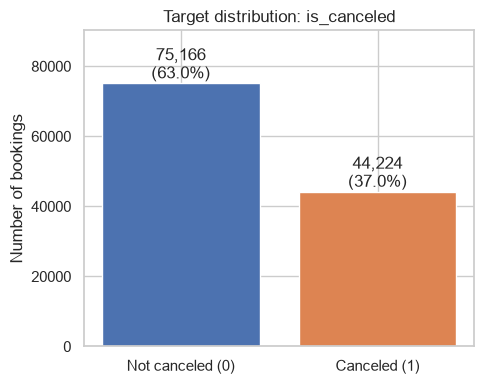

saved figure -> outputs\figures\3_target_distribution.png
Baseline accuracy ถ้าทายว่า "ไม่ยกเลิก" ทุกรายการ = 63.0%


In [9]:
counts = df_raw['is_canceled'].value_counts().sort_index()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Not canceled (0)', 'Canceled (1)'], counts.values, color=['#4C72B0', '#DD8452'])
for i, (c, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, c, f'{c:,}\n({p:.1f}%)', ha='center', va='bottom')
ax.set_ylim(0, counts.max() * 1.2)
ax.set_title('Target distribution: is_canceled')
ax.set_ylabel('Number of bookings')
save_fig('3_target_distribution')

print(f'Baseline accuracy ถ้าทายว่า "ไม่ยกเลิก" ทุกรายการ = {pct.max():.1f}%')

### 1.4 EDA: อัตราการยกเลิกแยกตามตัวแปรสำคัญ
เส้นประสีแดง = อัตรายกเลิกเฉลี่ยของทั้งชุดข้อมูล

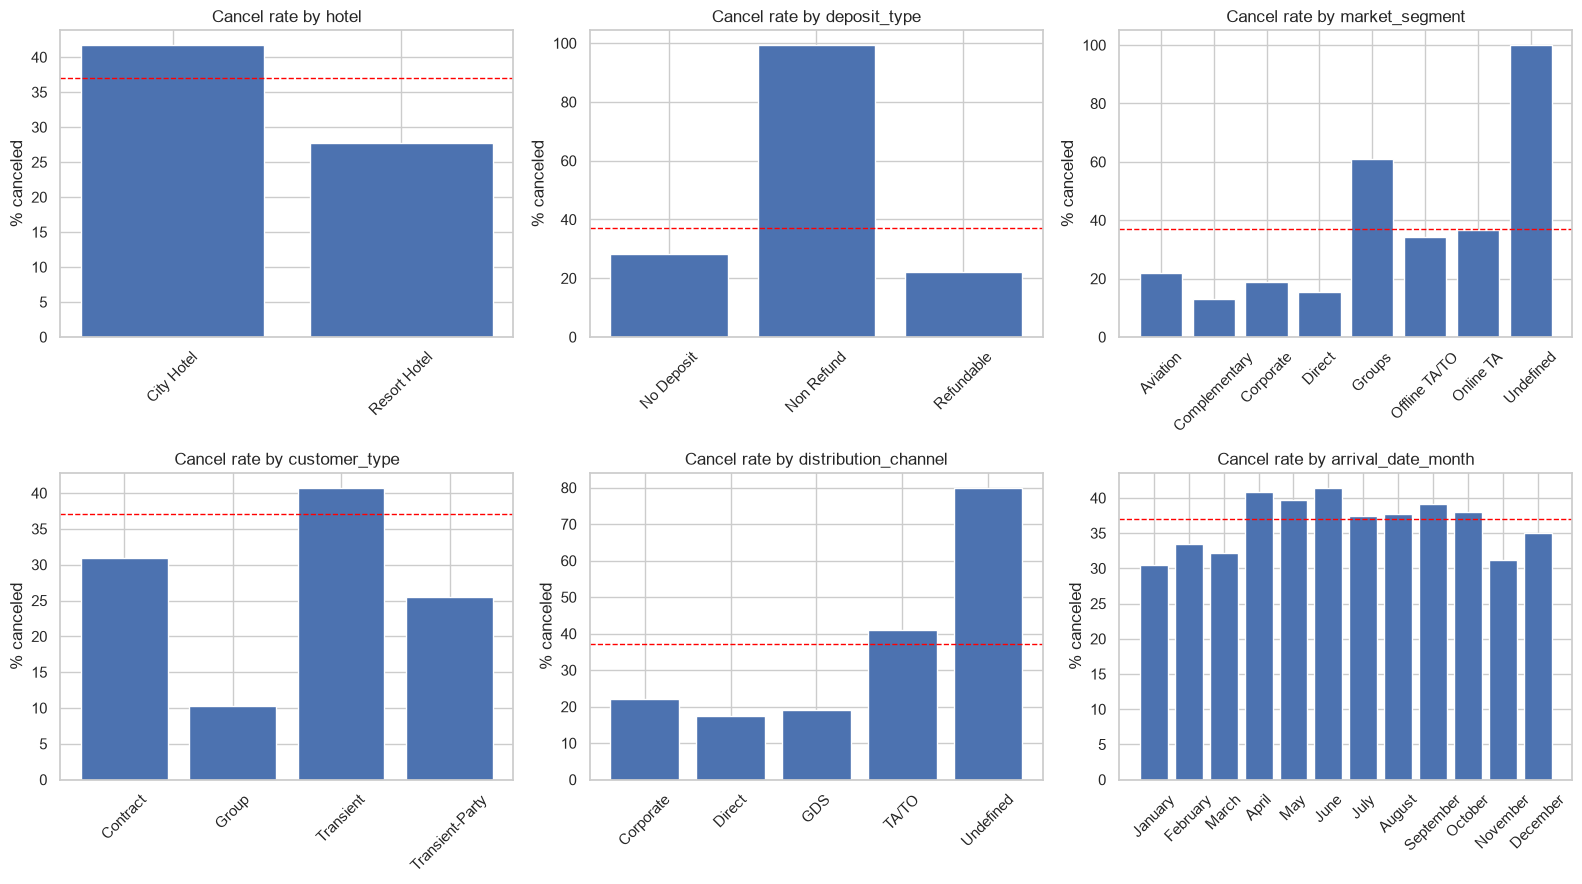

saved figure -> outputs\figures\3_eda_cancel_rate_by_category.png


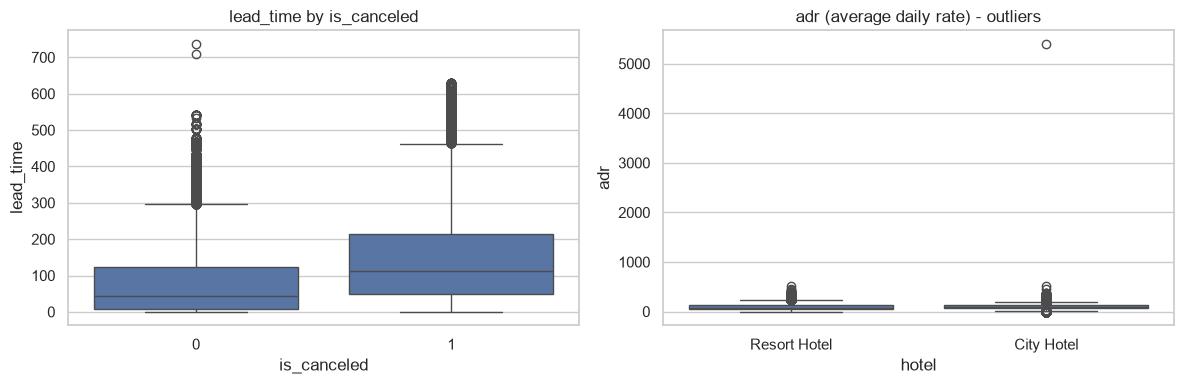

saved figure -> outputs\figures\3_eda_lead_time_and_adr.png
adr < 0            : 1
adr > 1000         : 1
ผู้เข้าพักรวม = 0  : 180


In [10]:
MONTHS = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
          'August', 'September', 'October', 'November', 'December']


def plot_cancel_rate(data, col, ax, order=None, target='is_canceled'):
    rate = data.groupby(col)[target].mean() * 100
    if order is not None:
        rate = rate.reindex([o for o in order if o in rate.index])
    ax.bar(rate.index.astype(str), rate.values, color='#4C72B0')
    ax.axhline(data[target].mean() * 100, ls='--', color='red', lw=1)
    ax.set_title(f'Cancel rate by {col}')
    ax.set_ylabel('% canceled')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)


eda_cols = ['hotel', 'deposit_type', 'market_segment', 'customer_type', 'distribution_channel']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for col, ax in zip(eda_cols, axes.flat):
    plot_cancel_rate(df_raw, col, ax)
plot_cancel_rate(df_raw, 'arrival_date_month', axes.flat[5], order=MONTHS)
save_fig('3_eda_cancel_rate_by_category')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df_raw, x='is_canceled', y='lead_time', ax=axes[0])
axes[0].set_title('lead_time by is_canceled')
sns.boxplot(data=df_raw, x='hotel', y='adr', ax=axes[1])
axes[1].set_title('adr (average daily rate) - outliers')
save_fig('3_eda_lead_time_and_adr')

total_guests_raw = df_raw['adults'] + df_raw['children'].fillna(0) + df_raw['babies']
print('adr < 0            :', (df_raw['adr'] < 0).sum())
print('adr > 1000         :', (df_raw['adr'] > 1000).sum())
print('ผู้เข้าพักรวม = 0  :', (total_guests_raw == 0).sum())

## 2. Data Preparation (หัวข้อ 4)
### 2.1 ตรวจ Data Leakage
- `reservation_status` / `reservation_status_date` บอกผลลัพธ์ตรงๆ → **ตัดทิ้งแน่นอน**
- `assigned_room_type` (ห้องที่ได้จริง) มักถูกกำหนดตอนเช็คอิน → ดูหลักฐานด้านล่างก่อนตัดสินใจ

In [11]:
print('reservation_status vs is_canceled')
display_tab = pd.crosstab(df_raw['reservation_status'], df_raw['is_canceled'])
print(display_tab, '\n')

room_changed = df_raw['reserved_room_type'] != df_raw['assigned_room_type']
leak_check = df_raw.assign(room_changed=room_changed).groupby('room_changed')['is_canceled'].agg(['mean', 'count'])
leak_check.columns = ['cancel_rate', 'n_bookings']
save_table(leak_check, '4_leakage_check_assigned_room')
print(leak_check)
print('\nถ้าการจองที่ "ถูกเปลี่ยนห้อง" แทบไม่เคยถูกยกเลิก แปลว่าข้อมูลนี้รู้หลังเช็คอิน -> leakage')

DROP_ASSIGNED_ROOM = True   # เปลี่ยนเป็น False ถ้าหลักฐานข้างบนไม่บ่งชี้ leakage

reservation_status vs is_canceled
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207 

saved table  -> outputs\tables\4_leakage_check_assigned_room.csv
              cancel_rate  n_bookings
room_changed                         
False            0.415629      104473
True             0.053764       14917

ถ้าการจองที่ "ถูกเปลี่ยนห้อง" แทบไม่เคยถูกยกเลิก แปลว่าข้อมูลนี้รู้หลังเช็คอิน -> leakage


### 2.2 Cleaning: จัดการ Missing, ค่าผิดปกติ และชนิดข้อมูล
ทุกขั้นตอนถูกบันทึกลงตาราง `4_preparation_log` เพื่อใช้ในรายงาน (ขั้นตอน → เหตุผล → จำนวนแถวที่ลบ)

In [12]:
ADR_MAX = 1000   # ราคาห้องต่อคืนที่สูงกว่านี้ถือว่าผิดปกติ

df = df_raw.copy()
prep_log = []


def log_step(step, reason, before, after):
    prep_log.append({'step': step, 'reason': reason, 'rows_before': before,
                     'rows_after': after, 'rows_removed': before - after})


n = len(df)
leak_cols = ['reservation_status', 'reservation_status_date'] + (['assigned_room_type'] if DROP_ASSIGNED_ROOM else [])
df = df.drop(columns=leak_cols)
log_step(f'drop {leak_cols}', 'data leakage: known only after the outcome', n, len(df))

n = len(df)
df['children'] = df['children'].fillna(0).astype(int)
log_step('children: NaN -> 0', 'only 4 missing; most bookings have no children', n, len(df))

df['country'] = df['country'].fillna('Unknown')
log_step("country: NaN -> 'Unknown'", 'missing country is a category of its own', n, len(df))

df['has_agent'] = df['agent'].notna().astype(int)
df['agent'] = df['agent'].map(lambda v: 'None' if pd.isna(v) else str(int(v)))
log_step("agent: NaN -> 'None' + has_agent flag", 'NaN means booked without a travel agent', n, len(df))

df['has_company'] = df['company'].notna().astype(int)
df = df.drop(columns=['company'])
log_step('company: drop column + has_company flag', '~94% missing; NaN means not a company booking', n, len(df))

df['meal'] = df['meal'].replace('Undefined', 'SC')
log_step("meal: 'Undefined' -> 'SC'", "dataset paper: Undefined/SC both mean no meal package", n, len(df))

n = len(df)
df = df[(df['adults'] + df['children'] + df['babies']) > 0]
log_step('remove rows with 0 guests', 'a booking without guests is invalid', n, len(df))

n = len(df)
df = df[(df['adr'] >= 0) & (df['adr'] <= ADR_MAX)]
log_step(f'remove adr < 0 or adr > {ADR_MAX}', 'impossible / extreme price', n, len(df))

df['arrival_date_month'] = df['arrival_date_month'].map({m: i + 1 for i, m in enumerate(MONTHS)})
df['arrival_date'] = pd.to_datetime(dict(year=df['arrival_date_year'],
                                         month=df['arrival_date_month'],
                                         day=df['arrival_date_day_of_month']))
log_step('arrival month -> number, build arrival_date', 'needed for season / weekday / time-based split', len(df), len(df))

# คอลัมน์ข้อความทั้งหมดเก็บเป็น object เพื่อให้ encoder ทำงานเหมือนกันทุกเวอร์ชันของ pandas
for c in df.columns:
    if not pd.api.types.is_numeric_dtype(df[c]) and c != 'arrival_date':
        df[c] = df[c].astype(object)
df = df.reset_index(drop=True)

prep_log = pd.DataFrame(prep_log)
save_table(prep_log, '4_preparation_log')
print(f'rows: {len(df_raw):,} -> {len(df):,} | missing ที่เหลือ = {int(df.isna().sum().sum())}')
prep_log

saved table  -> outputs\tables\4_preparation_log.csv
rows: 119,390 -> 119,208 | missing ที่เหลือ = 0


,step,reason,rows_before,rows_after,rows_removed
0,"drop ['reservation_status', 'reservation_statu...",data leakage: known only after the outcome,119390,119390,0
1,children: NaN -> 0,only 4 missing; most bookings have no children,119390,119390,0
2,country: NaN -> 'Unknown',missing country is a category of its own,119390,119390,0
3,agent: NaN -> 'None' + has_agent flag,NaN means booked without a travel agent,119390,119390,0
4,company: drop column + has_company flag,~94% missing; NaN means not a company booking,119390,119390,0
5,meal: 'Undefined' -> 'SC',dataset paper: Undefined/SC both mean no meal ...,119390,119390,0
6,remove rows with 0 guests,a booking without guests is invalid,119390,119210,180
7,remove adr < 0 or adr > 1000,impossible / extreme price,119210,119208,2
8,"arrival month -> number, build arrival_date",needed for season / weekday / time-based split,119208,119208,0


## 3. Feature Engineering (หัวข้อ 5.1)
แต่ละ feature มีสมมติฐานกำกับ การสร้าง feature ทำทีละแถวและไม่ได้เรียนรู้อะไรจากข้อมูลทั้งชุด จึง**ไม่ทำให้เกิด leakage** และทำก่อนแบ่ง train/test ได้

| Feature | สมมติฐาน |
|---|---|
| `total_nights` | ทริปยาวต้องวางแผนมาก → โอกาสยกเลิกต่างจากทริปสั้น |
| `total_guests` | กลุ่มใหญ่ประสานงานยาก → โอกาสเปลี่ยนแผนสูงขึ้น |
| `is_family` | ครอบครัวมีแผนชัดกว่า |
| `adr_per_person` | ราคาต่อหัวสะท้อนความคุ้มค่าได้ดีกว่าราคาห้องรวม |
| `lead_time_group` | ยิ่งจองล่วงหน้านาน แผนยิ่งเปลี่ยนได้ (ความสัมพันธ์ไม่เป็นเส้นตรง) |
| `cancel_history_ratio` | พฤติกรรมยกเลิกในอดีตบอกแนวโน้มในอนาคต |
| `season` | High season กับ Low season มีพฤติกรรมต่างกัน |
| `arrival_weekday` | เข้าพักวันธรรมดา (ธุรกิจ) vs วันหยุด (พักผ่อน) |
| `is_domestic` | ลูกค้าในประเทศ (โปรตุเกส) ยกเลิกง่ายกว่าเพราะเดินทางสะดวก |

In [13]:
LEAD_BINS   = [-1, 7, 30, 90, 180, 365, np.inf]
LEAD_LABELS = ['0-7', '8-30', '31-90', '91-180', '181-365', '365+']
SEASON = {12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring', 5: 'Spring',
          6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Autumn', 10: 'Autumn', 11: 'Autumn'}


def add_features(d):
    d = d.copy()
    d['total_nights'] = d['stays_in_weekend_nights'] + d['stays_in_week_nights']
    d['total_guests'] = d['adults'] + d['children'] + d['babies']
    d['is_family'] = ((d['children'] + d['babies']) > 0).astype(int)
    d['adr_per_person'] = d['adr'] / d['total_guests'].where(d['total_guests'] > 0, 1)
    d['lead_time_group'] = pd.cut(d['lead_time'], bins=LEAD_BINS, labels=LEAD_LABELS).astype(str).astype(object)
    past = d['previous_cancellations'] + d['previous_bookings_not_canceled']
    d['cancel_history_ratio'] = np.where(past > 0, d['previous_cancellations'] / past.where(past > 0, 1), 0.0)
    d['season'] = d['arrival_date_month'].map(SEASON).astype(object)
    d['arrival_weekday'] = d['arrival_date'].dt.dayofweek   # 0 = Monday
    d['is_domestic'] = (d['country'] == 'PRT').astype(int)
    return d


ENGINEERED_FEATURES = ['total_nights', 'total_guests', 'is_family', 'adr_per_person', 'lead_time_group',
                       'cancel_history_ratio', 'season', 'arrival_weekday', 'is_domestic']
df = add_features(df)
df[ENGINEERED_FEATURES].describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
total_nights,119208.0,NaN,NaN,NaN,3.426213,2.540633,0.0,2.0,3.0,4.0,69.0
total_guests,119208.0,NaN,NaN,NaN,1.97121,0.718882,1.0,2.0,2.0,2.0,55.0
is_family,119208.0,NaN,NaN,NaN,0.078283,0.268618,0.0,0.0,0.0,0.0,1.0
adr_per_person,119208.0,NaN,NaN,NaN,54.967253,28.030559,0.0,37.4,49.5,66.0,510.0
lead_time_group,119208,6,31-90,29528,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cancel_history_ratio,119208.0,NaN,NaN,NaN,0.050235,0.216633,0.0,0.0,0.0,0.0,1.0
season,119208,4,Summer,37434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_weekday,119208.0,NaN,NaN,NaN,2.996208,1.95199,0.0,1.0,3.0,5.0,6.0
is_domestic,119208.0,NaN,NaN,NaN,0.406701,0.49122,0.0,0.0,0.0,1.0,1.0


### 3.1 หลักฐาน: อัตรายกเลิกแยกตามกลุ่มของ feature ใหม่
ถ้าแต่ละกลุ่มมีอัตรายกเลิกต่างกันชัด แปลว่า feature นั้นมีพลังในการทำนาย (สนับสนุนสมมติฐาน)

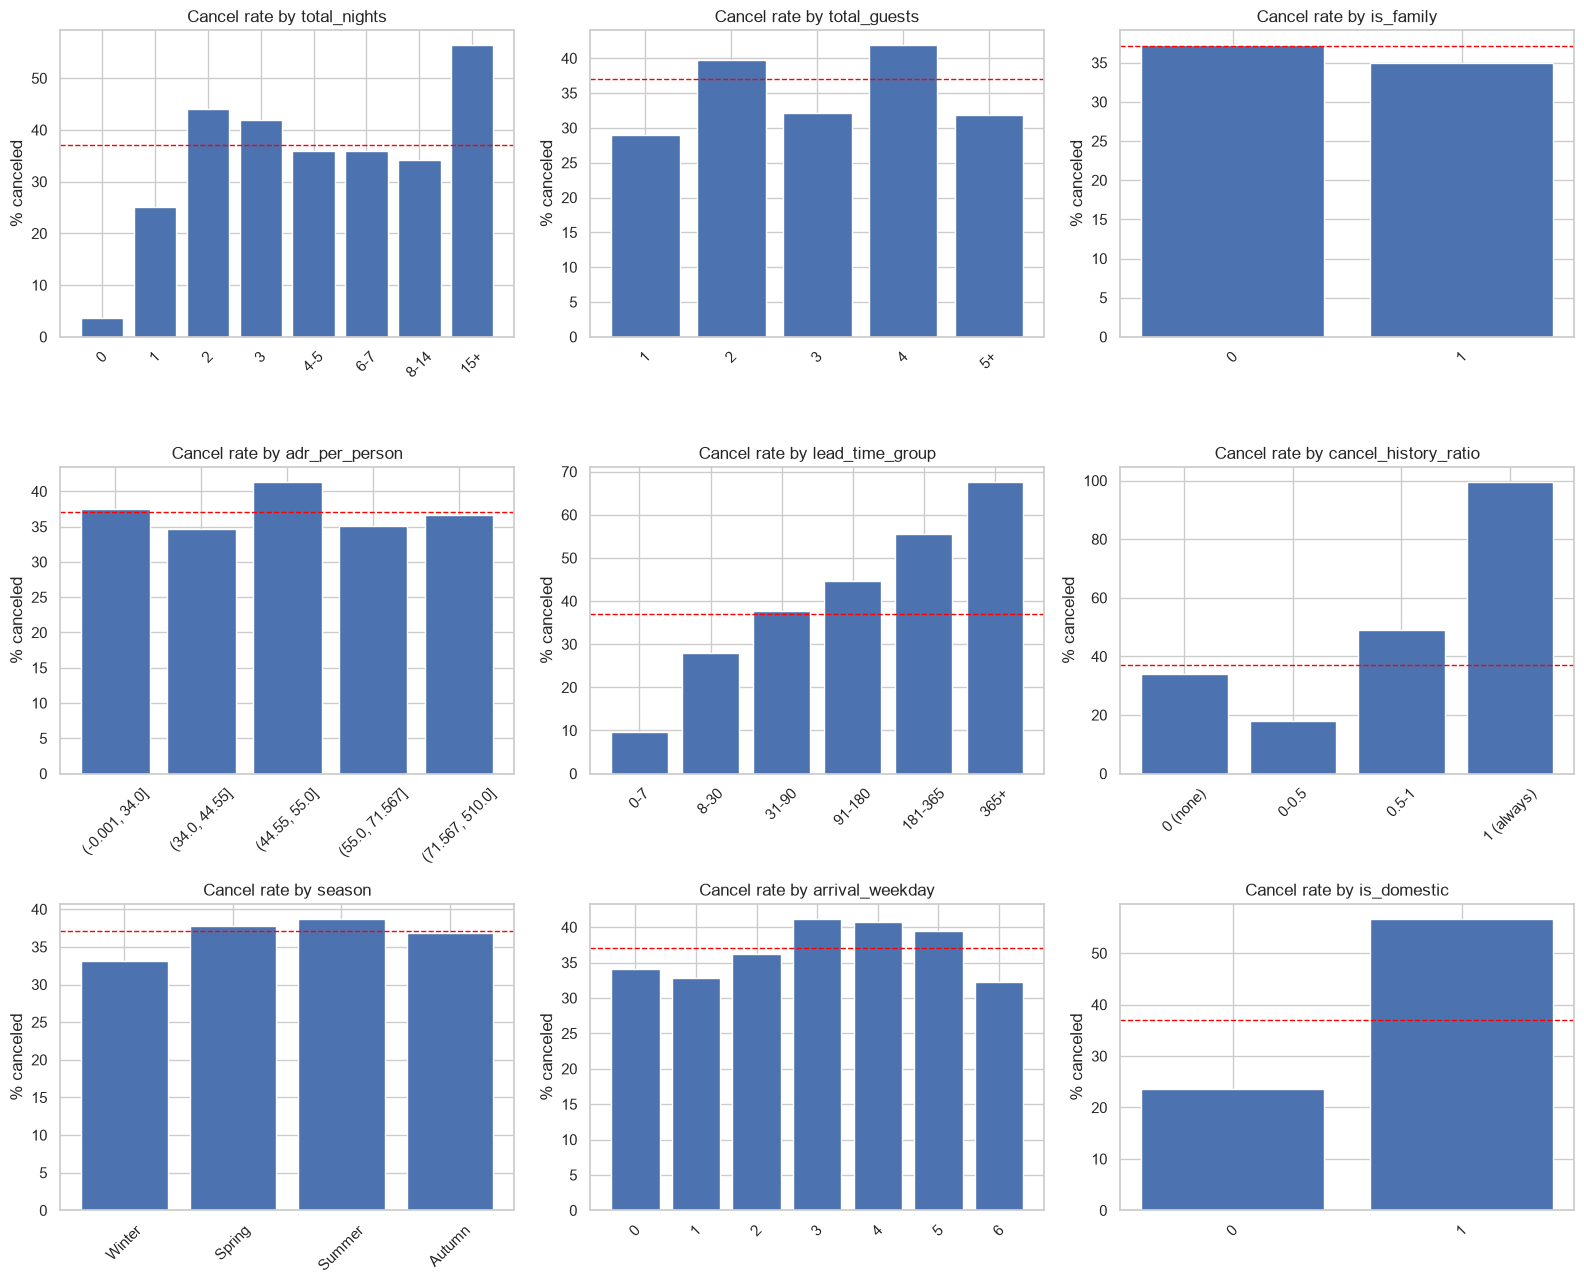

saved figure -> outputs\figures\5_engineered_features_cancel_rate.png
saved table  -> outputs\tables\5_engineered_features_spread.csv


,min_group_rate_%,max_group_rate_%,spread_%
cancel_history_ratio,18.0,99.6,81.6
lead_time_group,9.6,67.7,58.1
total_nights,3.6,56.4,52.8
is_domestic,23.6,56.7,33.1
total_guests,29.0,41.9,12.9
arrival_weekday,32.3,41.2,8.9
adr_per_person,34.6,41.4,6.8
season,33.1,38.8,5.7
is_family,34.9,37.3,2.4


In [14]:
plot_df = df[['is_canceled'] + ENGINEERED_FEATURES].copy()
plot_df['total_nights'] = pd.cut(plot_df['total_nights'], [-1, 0, 1, 2, 3, 5, 7, 14, np.inf],
                                 labels=['0', '1', '2', '3', '4-5', '6-7', '8-14', '15+'])
plot_df['total_guests'] = plot_df['total_guests'].clip(upper=5).astype(int).astype(str).replace('5', '5+')
plot_df['adr_per_person'] = pd.qcut(plot_df['adr_per_person'], 5, duplicates='drop').astype(str)
plot_df['cancel_history_ratio'] = pd.cut(plot_df['cancel_history_ratio'], [-0.01, 0, 0.5, 0.999, 1],
                                         labels=['0 (none)', '0-0.5', '0.5-1', '1 (always)'])

orders = {'lead_time_group': LEAD_LABELS, 'season': ['Winter', 'Spring', 'Summer', 'Autumn']}
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
for col, ax in zip(ENGINEERED_FEATURES, axes.flat):
    plot_cancel_rate(plot_df, col, ax, order=orders.get(col))
save_fig('5_engineered_features_cancel_rate')

eng_summary = pd.DataFrame({
    col: {'min_group_rate_%': plot_df.groupby(col)['is_canceled'].mean().min() * 100,
          'max_group_rate_%': plot_df.groupby(col)['is_canceled'].mean().max() * 100}
    for col in ENGINEERED_FEATURES}).T.round(1)
eng_summary['spread_%'] = eng_summary['max_group_rate_%'] - eng_summary['min_group_rate_%']
save_table(eng_summary.sort_values('spread_%', ascending=False), '5_engineered_features_spread')

## 4. แบ่งข้อมูล Train/Test + Baseline
- **Feature Set A** = feature เดิม (หลังตัด leakage) · **Feature Set B** = A + feature ใหม่
- ตัด `arrival_date_year` ออก เพราะปีในอนาคตไม่เคยเห็นในข้อมูล train (ใช้ทำนายอนาคตไม่ได้)
- แบ่ง 2 แบบ: **(a) Stratified Random Split 80/20** และ **(b) Time-based Split** (train = ช่วงแรก 80%, test = ช่วงหลัง 20%)
- Test set ถูกใช้**ครั้งเดียว**ในส่วน 7.5 เท่านั้น ส่วนการเลือก feature และ tuning ทำด้วย Cross-Validation บน train

In [15]:
TARGET = 'is_canceled'
ORIGINAL_FEATURES = ['hotel', 'lead_time', 'arrival_date_month', 'arrival_date_week_number',
                     'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights',
                     'adults', 'children', 'babies', 'meal', 'country', 'market_segment',
                     'distribution_channel', 'is_repeated_guest', 'previous_cancellations',
                     'previous_bookings_not_canceled', 'reserved_room_type', 'booking_changes',
                     'deposit_type', 'agent', 'has_agent', 'has_company', 'days_in_waiting_list',
                     'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']
if not DROP_ASSIGNED_ROOM:
    ORIGINAL_FEATURES.append('assigned_room_type')

FEATURES_A = ORIGINAL_FEATURES
FEATURES_B = ORIGINAL_FEATURES + ENGINEERED_FEATURES

if QUICK_RUN:
    df = df.sample(n=min(15000, len(df)), random_state=RANDOM_STATE).reset_index(drop=True)

# (a) Stratified random split
X_train, X_test, y_train, y_test = train_test_split(
    df[FEATURES_B], df[TARGET], test_size=0.2, stratify=df[TARGET], random_state=RANDOM_STATE)

# (b) Time-based split
cutoff = df['arrival_date'].quantile(0.8)
time_train = df[df['arrival_date'] < cutoff]
time_test  = df[df['arrival_date'] >= cutoff]

split_info = pd.DataFrame({
    'rows': [len(X_train), len(X_test), len(time_train), len(time_test)],
    'cancel_rate_%': [y_train.mean() * 100, y_test.mean() * 100,
                      time_train[TARGET].mean() * 100, time_test[TARGET].mean() * 100],
    'date_from': [df.loc[X_train.index, 'arrival_date'].min(), df.loc[X_test.index, 'arrival_date'].min(),
                  time_train['arrival_date'].min(), time_test['arrival_date'].min()],
    'date_to': [df.loc[X_train.index, 'arrival_date'].max(), df.loc[X_test.index, 'arrival_date'].max(),
                time_train['arrival_date'].max(), time_test['arrival_date'].max()],
}, index=['random_train', 'random_test', 'time_train', 'time_test']).round(2)
save_table(split_info, '4_split_summary')
print('Feature set A =', len(FEATURES_A), 'features | Feature set B =', len(FEATURES_B), 'features')
split_info

saved table  -> outputs\tables\4_split_summary.csv
Feature set A = 28 features | Feature set B = 37 features


,rows,cancel_rate_%,date_from,date_to
random_train,95366,37.08,2015-07-01,2017-08-31
random_test,23842,37.08,2015-07-01,2017-08-31
time_train,95190,36.09,2015-07-01,2017-04-21
time_test,24018,40.99,2017-04-22,2017-08-31


### 4.1 Preprocessing Pipeline และฟังก์ชันช่วย
- **Logistic Regression** → numeric: เติม median + StandardScaler · categorical: One-Hot Encoding
- **Tree models** → numeric: เติม median (ไม่ต้อง scale) · categorical: Ordinal Encoding
- ค่าที่พบน้อยกว่า 50 ครั้ง (เช่น ประเทศเล็กๆ, agent ที่ใช้น้อย) รวมเป็นกลุ่ม "infrequent" เพื่อลด cardinality
- ทุกขั้นอยู่ใน `Pipeline` → encoder/scaler **เรียนรู้จาก train ของแต่ละ fold เท่านั้น** (ไม่มี leakage)

In [16]:
MIN_FREQ = 50
SCORING = {'f1': 'f1', 'roc_auc': 'roc_auc', 'pr_auc': 'average_precision',
           'precision': 'precision', 'recall': 'recall', 'accuracy': 'accuracy'}
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
CV3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)


def split_cols(features):
    cat = [c for c in features if not pd.api.types.is_numeric_dtype(df[c])]
    num = [c for c in features if c not in cat]
    return num, cat


def make_preprocessor(features, kind):
    num, cat = split_cols(features)
    if kind == 'linear':
        num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())])
        cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                             ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=MIN_FREQ))])
    else:
        num_pipe = SimpleImputer(strategy='median')
        cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                             ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1,
                                                        min_frequency=MIN_FREQ))])
    return ColumnTransformer([('num', num_pipe, num), ('cat', cat_pipe, cat)])


def make_estimator(name):
    return {
        'Dummy': DummyClassifier(strategy='most_frequent'),
        'LogisticRegression': LogisticRegression(max_iter=2000),
        'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'RandomForest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
        'HistGradientBoosting': HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    }[name]


def make_model(name, features, params=None):
    kind = 'linear' if name == 'LogisticRegression' else 'tree'
    pipe = Pipeline([('prep', make_preprocessor(features, kind)), ('model', make_estimator(name))])
    if params:
        pipe.set_params(**params)
    return pipe


def evaluate_cv(pipe, X, y, cv=None, train_score=False):
    res = cross_validate(pipe, X, y, cv=cv or CV, scoring=SCORING, n_jobs=-1, return_train_score=train_score)
    row = {}
    for m in SCORING:
        row[f'{m}_mean'] = res[f'test_{m}'].mean()
        row[f'{m}_std'] = res[f'test_{m}'].std()
    if train_score:
        row['train_f1_mean'] = res['train_f1'].mean()
        row['gap_f1(train-cv)'] = row['train_f1_mean'] - row['f1_mean']
    row['fit_time_s'] = res['fit_time'].mean()
    return row


def test_metrics(y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    return {'threshold': threshold,
            'f1': f1_score(y_true, pred), 'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred), 'accuracy': accuracy_score(y_true, pred),
            'roc_auc': roc_auc_score(y_true, proba), 'pr_auc': average_precision_score(y_true, proba)}


def stratified_sample(X, y, frac):
    if frac >= 1:
        return X, y
    Xs, _, ys, _ = train_test_split(X, y, train_size=frac, stratify=y, random_state=RANDOM_STATE)
    return Xs, ys


print('numeric / categorical ใน Feature Set B:', [len(x) for x in split_cols(FEATURES_B)])

numeric / categorical ใน Feature Set B: [26, 11]


### 4.2 Baseline
Dummy Classifier (ทายคลาสที่พบบ่อยที่สุดเสมอ) คือเกณฑ์ขั้นต่ำ โมเดลที่ดีต้องชนะ baseline นี้ให้ได้ชัดเจน
Accuracy ของ Dummy สูง แต่ F1 = 0 → เป็นหลักฐานว่า **Accuracy ไม่เหมาะกับข้อมูลที่ไม่สมดุล**

In [17]:
baseline = pd.DataFrame({
    'Dummy (most frequent)': evaluate_cv(make_model('Dummy', FEATURES_A), X_train[FEATURES_A], y_train),
    'LogisticRegression (Set A)': evaluate_cv(make_model('LogisticRegression', FEATURES_A), X_train[FEATURES_A], y_train),
}).T.round(4)
save_table(baseline, '7_baseline')
baseline[['accuracy_mean', 'f1_mean', 'roc_auc_mean', 'pr_auc_mean']]

saved table  -> outputs\tables\7_baseline.csv


,accuracy_mean,f1_mean,roc_auc_mean,pr_auc_mean
Dummy (most frequent),0.6292,0.0000,0.5000,0.3708
LogisticRegression (Set A),0.8249,0.7456,0.9049,0.8641


## 5. Feature Selection (หัวข้อ 5.2–5.3)
ใช้ 3 วิธีจาก 3 แนวคิด แล้วโหวต (**คำนวณจาก train set เท่านั้น**)
1. **Filter**: Correlation + Mutual Information (ดูความสัมพันธ์ทางสถิติ ยังไม่ใช้โมเดล)
2. **Embedded**: Random Forest Feature Importance (ได้มาระหว่าง train)
3. **Model-agnostic**: Permutation Importance (สลับค่าคอลัมน์แล้ววัดว่าโมเดลแย่ลงแค่ไหน)

### 5.1 Correlation (หาตัวแปรที่ซ้ำซ้อนกัน)

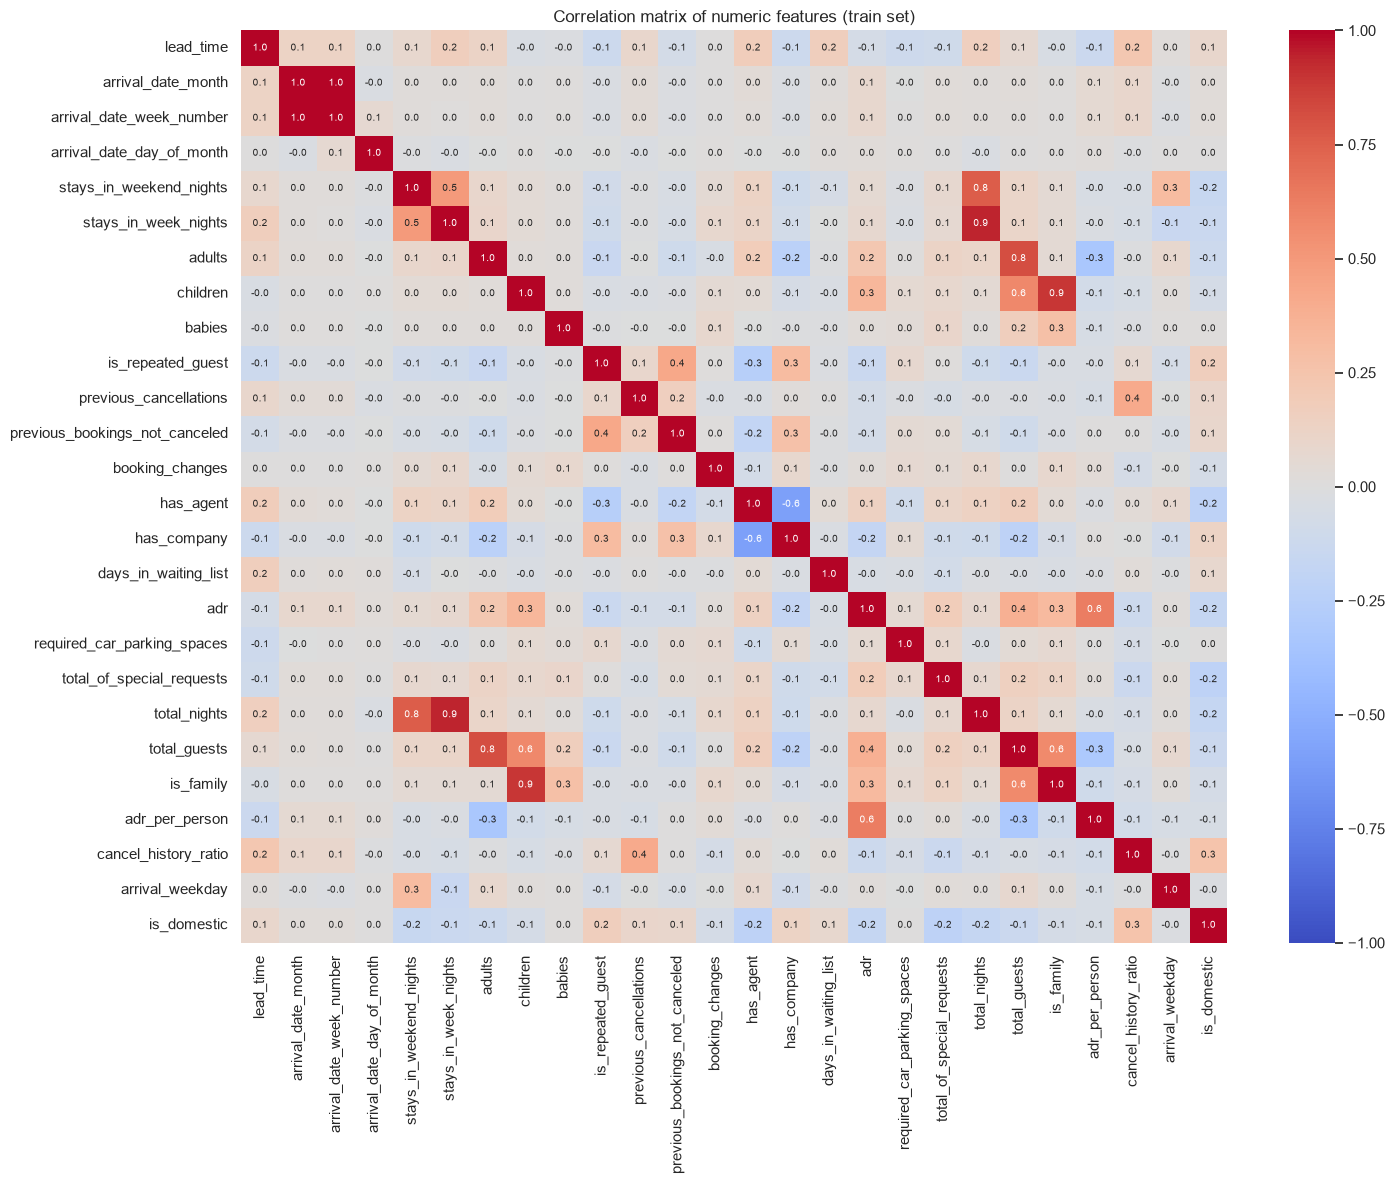

saved figure -> outputs\figures\5_correlation_heatmap.png
saved table  -> outputs\tables\5_high_correlation_pairs.csv
คู่ที่ |r| >= 0.7 (ซ้ำซ้อนกัน):


,feature_1,feature_2,corr
28,arrival_date_month,arrival_date_week_number,0.995103
149,stays_in_week_nights,total_nights,0.940267
203,children,is_family,0.895156
176,adults,total_guests,0.819276
123,stays_in_weekend_nights,total_nights,0.760031


In [18]:
num_B, cat_B = split_cols(FEATURES_B)
corr = X_train[num_B].corr()

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, vmin=-1, vmax=1, annot=True, fmt='.1f',
            annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlation matrix of numeric features (train set)')
save_fig('5_correlation_heatmap')

pairs = (corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
         .rename('corr').reset_index().rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2'}))
high_corr = pairs[pairs['corr'].abs() >= 0.7].sort_values('corr', key=abs, ascending=False)
save_table(high_corr.set_index('feature_1'), '5_high_correlation_pairs')
print('คู่ที่ |r| >= 0.7 (ซ้ำซ้อนกัน):')
high_corr

### 5.2 Mutual Information
วัดว่าแต่ละ feature ให้ข้อมูลเกี่ยวกับการยกเลิกมากแค่ไหน (จับความสัมพันธ์แบบไม่เป็นเส้นตรงได้ ต่างจาก correlation)

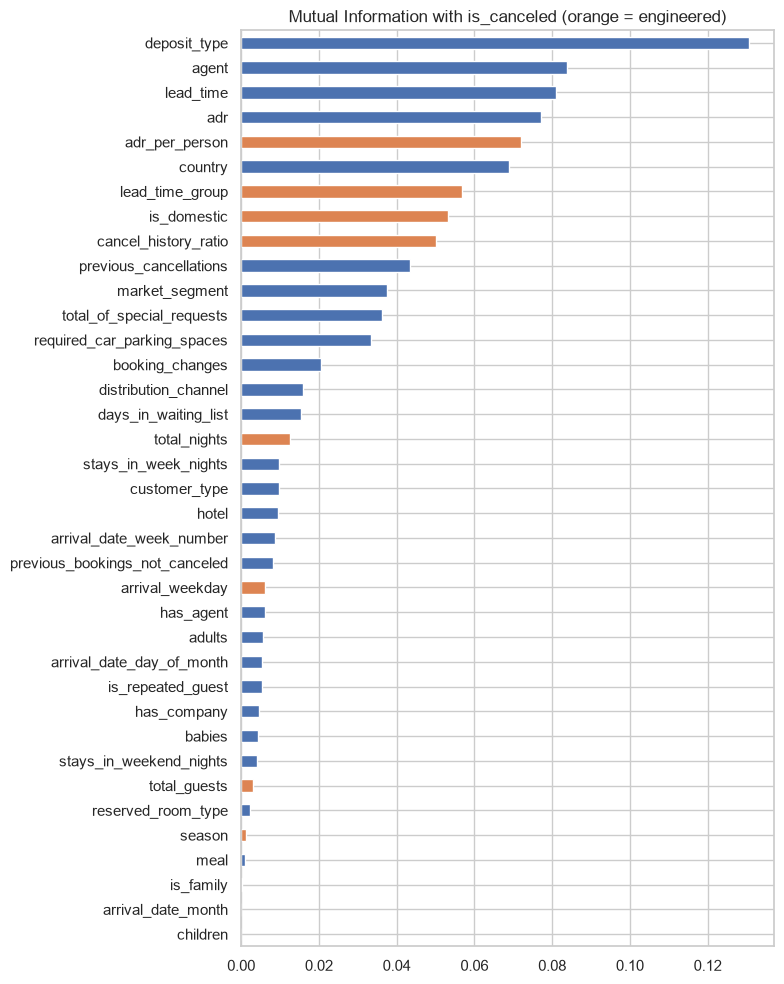

saved figure -> outputs\figures\5_mutual_information.png


In [19]:
X_mi = X_train[FEATURES_B].copy()
X_mi[cat_B] = OrdinalEncoder().fit_transform(X_mi[cat_B].astype(str))
X_mi_s, y_mi_s = stratified_sample(X_mi, y_train, min(1.0, 30000 / len(X_mi)))
mi = mutual_info_classif(X_mi_s, y_mi_s, discrete_features=[c in cat_B for c in FEATURES_B],
                         random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=FEATURES_B).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
mi_scores.sort_values().plot(kind='barh', ax=ax,
                             color=['#DD8452' if f in ENGINEERED_FEATURES else '#4C72B0' for f in mi_scores.sort_values().index])
ax.set_title('Mutual Information with is_canceled (orange = engineered)')
save_fig('5_mutual_information')

### 5.3 Random Forest Feature Importance

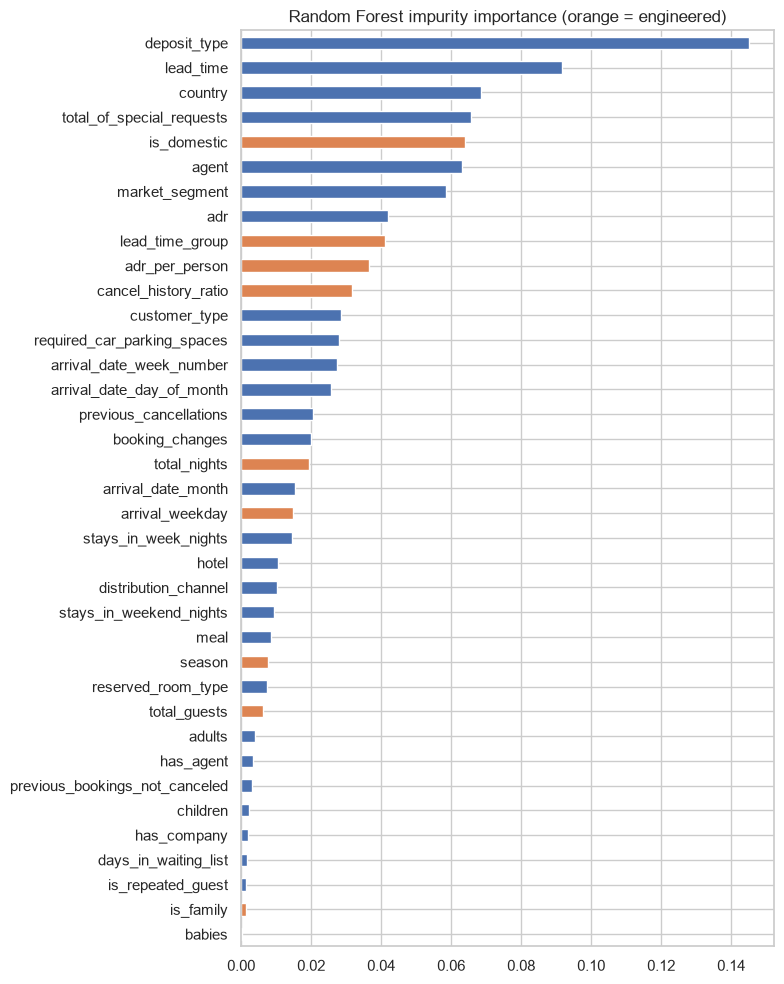

saved figure -> outputs\figures\5_random_forest_importance.png


In [20]:
rf_pipe = make_model('RandomForest', FEATURES_B, {'model__min_samples_leaf': 5})
rf_pipe.fit(X_train[FEATURES_B], y_train)
num_names, cat_names = split_cols(FEATURES_B)
rf_scores = pd.Series(rf_pipe.named_steps['model'].feature_importances_,
                      index=num_names + cat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 10))
rf_scores.sort_values().plot(kind='barh', ax=ax,
                             color=['#DD8452' if f in ENGINEERED_FEATURES else '#4C72B0' for f in rf_scores.sort_values().index])
ax.set_title('Random Forest impurity importance (orange = engineered)')
save_fig('5_random_forest_importance')

### 5.4 Permutation Importance
Impurity importance ของ Random Forest **มีอคติ ชอบให้คะแนนสูงกับตัวแปรที่มีค่าหลากหลาย** (เช่น `adr`, `agent`, `country`)
จึงใช้ Permutation Importance บน validation set ยืนยันอีกชั้น

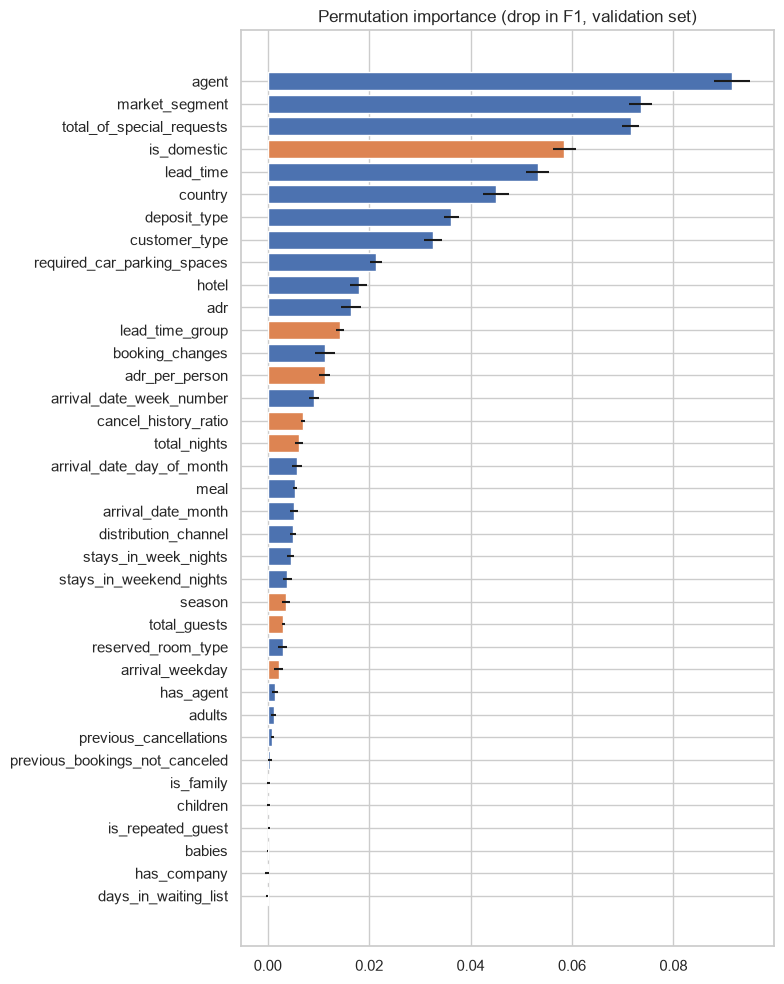

saved figure -> outputs\figures\5_permutation_importance.png


In [21]:
X_fit, X_val, y_fit, y_val = train_test_split(X_train[FEATURES_B], y_train, test_size=0.2,
                                              stratify=y_train, random_state=RANDOM_STATE)
perm_pipe = make_model('RandomForest', FEATURES_B, {'model__min_samples_leaf': 5}).fit(X_fit, y_fit)
X_val_s, y_val_s = stratified_sample(X_val, y_val, min(1.0, 10000 / len(X_val)))
perm = permutation_importance(perm_pipe, X_val_s, y_val_s, scoring='f1', n_repeats=PERM_REPEATS,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm_scores = pd.Series(perm.importances_mean, index=FEATURES_B).sort_values(ascending=False)
perm_std = pd.Series(perm.importances_std, index=FEATURES_B).reindex(perm_scores.index)

fig, ax = plt.subplots(figsize=(8, 10))
order = perm_scores.sort_values().index
ax.barh(order, perm_scores[order], xerr=perm_std[order],
        color=['#DD8452' if f in ENGINEERED_FEATURES else '#4C72B0' for f in order])
ax.set_title('Permutation importance (drop in F1, validation set)')
save_fig('5_permutation_importance')

### 5.5 ตารางโหวต
feature ได้ 1 โหวตจากแต่ละวิธีที่จัดให้อยู่ใน Top-N → **เก็บ feature ที่ได้ ≥ 2 ใน 3 โหวต** = Feature Set C

In [22]:
TOP_N = max(10, len(FEATURES_B) // 2)
ranks = pd.DataFrame({
    'MI_rank': mi_scores.rank(ascending=False),
    'RF_rank': rf_scores.rank(ascending=False),
    'Perm_rank': perm_scores.rank(ascending=False),
}).reindex(FEATURES_B)
votes = (ranks <= TOP_N).astype(int)
votes.columns = ['MI_vote', 'RF_vote', 'Perm_vote']
vote_table = pd.concat([ranks, votes], axis=1)
vote_table['total_votes'] = votes.sum(axis=1)
vote_table['mean_rank'] = ranks.mean(axis=1)
vote_table['engineered'] = vote_table.index.isin(ENGINEERED_FEATURES)
vote_table['decision'] = np.where(vote_table['total_votes'] >= 2, 'keep', 'drop')
vote_table = vote_table.sort_values(['total_votes', 'mean_rank'], ascending=[False, True])
save_table(vote_table, '5_feature_vote_table')

FEATURES_C = vote_table.index[vote_table['decision'] == 'keep'].tolist()
print(f'TOP_N = {TOP_N} | Feature Set C = {len(FEATURES_C)} features')
print('ตัดออก:', vote_table.index[vote_table['decision'] == 'drop'].tolist())
vote_table

saved table  -> outputs\tables\5_feature_vote_table.csv
TOP_N = 18 | Feature Set C = 18 features
ตัดออก: ['hotel', 'distribution_channel', 'stays_in_week_nights', 'days_in_waiting_list', 'arrival_weekday', 'arrival_date_month', 'stays_in_weekend_nights', 'meal', 'has_agent', 'adults', 'season', 'previous_bookings_not_canceled', 'total_guests', 'reserved_room_type', 'is_repeated_guest', 'has_company', 'babies', 'children', 'is_family']


,MI_rank,RF_rank,Perm_rank,MI_vote,RF_vote,Perm_vote,total_votes,mean_rank,engineered,decision
deposit_type,1.0,1.0,7.0,1,1,1,3,3.000000,False,keep
agent,2.0,6.0,1.0,1,1,1,3,3.000000,False,keep
lead_time,3.0,2.0,5.0,1,1,1,3,3.333333,False,keep
country,6.0,3.0,6.0,1,1,1,3,5.000000,False,keep
is_domestic,8.0,5.0,4.0,1,1,1,3,5.666667,True,keep
total_of_special_requests,12.0,4.0,3.0,1,1,1,3,6.333333,False,keep
market_segment,11.0,7.0,2.0,1,1,1,3,6.666667,False,keep
adr,4.0,8.0,11.0,1,1,1,3,7.666667,False,keep
lead_time_group,7.0,9.0,12.0,1,1,1,3,9.333333,True,keep
adr_per_person,5.0,10.0,14.0,1,1,1,3,9.666667,True,keep


### 5.6 ประสิทธิภาพ vs จำนวน Feature (K)
เรียง feature ตาม mean rank แล้วเพิ่มทีละ K ใช้ตอบคำถาม **"ทำไมเลือก K เท่านี้?"** โดยดูจุดที่กราฟเริ่มแบน

saved table  -> outputs\tables\5_performance_vs_k.csv


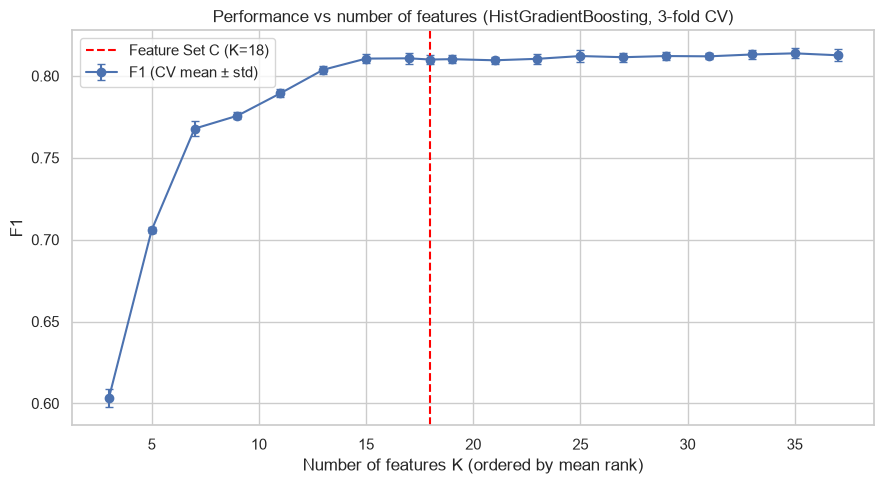

saved figure -> outputs\figures\5_performance_vs_k.png


,f1_mean,f1_std,roc_auc_mean
K,,,
3,0.6031,0.0056,0.8351
5,0.7059,0.0017,0.8935
7,0.7678,0.0047,0.9132
9,0.7757,0.0022,0.9175
11,0.7894,0.0024,0.9280
13,0.8038,0.0024,0.9372
15,0.8106,0.0026,0.9404
17,0.8107,0.0035,0.9411
18,0.8100,0.0030,0.9411


In [23]:
ranked = vote_table.sort_values('mean_rank').index.tolist()
k_step = 4 if QUICK_RUN else 2
k_values = sorted(set(list(range(3, len(ranked) + 1, k_step)) + [len(ranked), len(FEATURES_C)]))
k_rows = []
for k in k_values:
    feats = ranked[:k]
    res = cross_validate(make_model('HistGradientBoosting', feats), X_train[feats], y_train,
                         cv=CV3, scoring=['f1', 'roc_auc'], n_jobs=-1)
    k_rows.append({'K': k, 'f1_mean': res['test_f1'].mean(), 'f1_std': res['test_f1'].std(),
                   'roc_auc_mean': res['test_roc_auc'].mean()})
k_curve = pd.DataFrame(k_rows).set_index('K')
save_table(k_curve, '5_performance_vs_k')

fig, ax = plt.subplots(figsize=(9, 5))
ax.errorbar(k_curve.index, k_curve['f1_mean'], yerr=k_curve['f1_std'], marker='o', capsize=3, label='F1 (CV mean ± std)')
ax.axvline(len(FEATURES_C), color='red', ls='--', label=f'Feature Set C (K={len(FEATURES_C)})')
ax.set_xlabel('Number of features K (ordered by mean rank)')
ax.set_ylabel('F1')
ax.set_title('Performance vs number of features (HistGradientBoosting, 3-fold CV)')
ax.legend()
save_fig('5_performance_vs_k')
k_curve.round(4)

### 5.7 เปรียบเทียบ Feature Set A / B / C
โมเดลเดียวกัน (HistGradientBoosting ค่า default) + Cross-Validation แบบเดียวกัน → เปลี่ยนแค่ชุด feature

In [24]:
abc_rows = {}
for label, feats in [('A: original', FEATURES_A), ('B: original + engineered', FEATURES_B), ('C: selected', FEATURES_C)]:
    row = evaluate_cv(make_model('HistGradientBoosting', feats), X_train[feats], y_train)
    row['n_features'] = len(feats)
    abc_rows[label] = row
abc = pd.DataFrame(abc_rows).T
abc = abc[['n_features', 'f1_mean', 'f1_std', 'roc_auc_mean', 'roc_auc_std', 'pr_auc_mean', 'fit_time_s']].round(4)
save_table(abc, '5_feature_set_comparison')
print('หมายเหตุ: ถ้าผลต่างของ F1 น้อยกว่า std ถือว่า "ไม่ต่างกันอย่างมีนัยสำคัญ"')
abc

saved table  -> outputs\tables\5_feature_set_comparison.csv
หมายเหตุ: ถ้าผลต่างของ F1 น้อยกว่า std ถือว่า "ไม่ต่างกันอย่างมีนัยสำคัญ"


,n_features,f1_mean,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,fit_time_s
A: original,28.0,0.8103,0.0049,0.9420,0.0010,0.9157,7.5429
B: original + engineered,37.0,0.8127,0.0042,0.9428,0.0010,0.9165,9.1473
C: selected,18.0,0.8112,0.0027,0.9417,0.0009,0.9154,5.5475


In [25]:
FINAL_FEATURES = FEATURES_C   # เปลี่ยนเป็น FEATURES_B ได้ ถ้าตาราง 5.7 แสดงว่า B ดีกว่าชัดเจน
print(len(FINAL_FEATURES), 'features ->', FINAL_FEATURES)
X_train_f, X_test_f = X_train[FINAL_FEATURES], X_test[FINAL_FEATURES]

18 features -> ['deposit_type', 'agent', 'lead_time', 'country', 'is_domestic', 'total_of_special_requests', 'market_segment', 'adr', 'lead_time_group', 'adr_per_person', 'required_car_parking_spaces', 'cancel_history_ratio', 'booking_changes', 'total_nights', 'customer_type', 'arrival_date_week_number', 'previous_cancellations', 'arrival_date_day_of_month']


## 6. Model Development (หัวข้อ 6)
เทียบ 5 โมเดลจากง่ายไปซับซ้อน ด้วยค่า default ทั้งหมด (ผล "ก่อน tuning")
คอลัมน์ `gap_f1(train-cv)` ใช้ดู **overfitting** (ช่องว่างยิ่งกว้าง ยิ่ง overfit)

saved table  -> outputs\tables\6_default_models_cv.csv


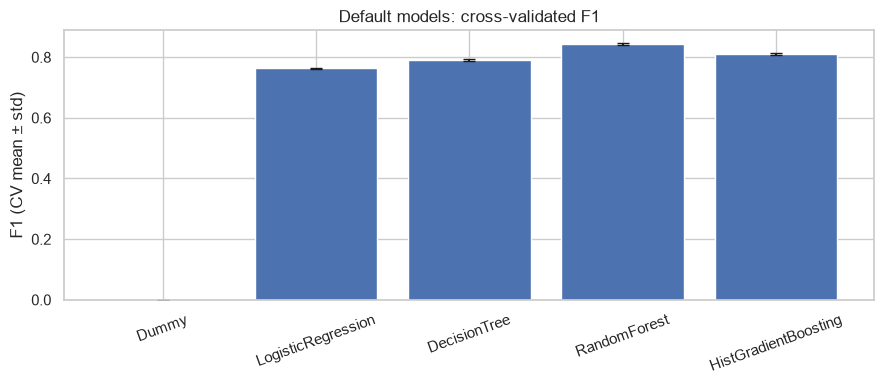

saved figure -> outputs\figures\6_default_models_f1.png


,f1_mean,f1_std,roc_auc_mean,pr_auc_mean,precision_mean,recall_mean,accuracy_mean,train_f1_mean,gap_f1(train-cv),fit_time_s
Dummy,0.0000,0.0000,0.5000,0.3708,0.0000,0.0000,0.6292,0.0000,0.0000,1.5794
LogisticRegression,0.7629,0.0021,0.9119,0.8769,0.8152,0.7170,0.8348,0.7641,0.0012,3.3228
DecisionTree,0.7908,0.0033,0.8360,0.7051,0.7862,0.7956,0.8440,0.9942,0.2034,2.4204
RandomForest,0.8422,0.0036,0.9546,0.9358,0.8720,0.8143,0.8868,0.9942,0.1521,50.2354
HistGradientBoosting,0.8112,0.0027,0.9417,0.9154,0.8503,0.7756,0.8661,0.8222,0.0110,5.4569


In [26]:
MODEL_NAMES = ['Dummy', 'LogisticRegression', 'DecisionTree', 'RandomForest', 'HistGradientBoosting']
default_results = pd.DataFrame({
    name: evaluate_cv(make_model(name, FINAL_FEATURES), X_train_f, y_train, train_score=True)
    for name in MODEL_NAMES}).T
default_results = default_results[['f1_mean', 'f1_std', 'roc_auc_mean', 'pr_auc_mean', 'precision_mean',
                                   'recall_mean', 'accuracy_mean', 'train_f1_mean', 'gap_f1(train-cv)',
                                   'fit_time_s']].round(4)
save_table(default_results, '6_default_models_cv')

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(default_results.index, default_results['f1_mean'], yerr=default_results['f1_std'], capsize=4, color='#4C72B0')
ax.set_ylabel('F1 (CV mean ± std)')
ax.set_title('Default models: cross-validated F1')
ax.tick_params(axis='x', rotation=20)
save_fig('6_default_models_f1')
default_results

## 7. Model Evaluation & Hyperparameter Tuning (หัวข้อ 7)
### 7.1 ขั้นที่ 1: RandomizedSearchCV (ค้นแบบกว้าง)
- Tuning 3 โมเดลหลัก: Logistic Regression, Random Forest, HistGradientBoosting
- ใช้ข้อมูล train บางส่วน (`TUNE_FRAC`) และ 3-fold CV เพื่อประหยัดเวลา · เลือกค่าที่ดีที่สุดด้วย **F1**
- ⏳ **cell นี้ใช้เวลานานที่สุด** ผลทุกชุดจะถูกบันทึกลง `tables/7_random_search_*.csv`

In [27]:
TUNE_MODELS = ['LogisticRegression', 'RandomForest', 'HistGradientBoosting']
PARAM_DISTRIBUTIONS = {
    'LogisticRegression': {
        'model__C': loguniform(1e-3, 1e2),
        'model__class_weight': [None, 'balanced'],
    },
    'RandomForest': {
        'model__n_estimators': [200, 300, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_leaf': [1, 2, 5, 10],
        'model__max_features': ['sqrt', 'log2', 0.3, 0.5],
        'model__class_weight': [None, 'balanced', 'balanced_subsample'],
    },
    'HistGradientBoosting': {
        'model__learning_rate': loguniform(0.02, 0.3),
        'model__max_leaf_nodes': [15, 31, 63, 127],
        'model__max_depth': [None, 6, 10],
        'model__min_samples_leaf': [20, 50, 100],
        'model__l2_regularization': loguniform(1e-3, 10),
        'model__class_weight': [None, 'balanced'],
    },
}

X_tune, y_tune = stratified_sample(X_train_f, y_train, TUNE_FRAC)
print(f'tuning on {len(X_tune):,} rows ({TUNE_FRAC:.0%} of train)')

random_search = {}
for name in TUNE_MODELS:
    t0 = time.time()
    search = RandomizedSearchCV(make_model(name, FINAL_FEATURES), PARAM_DISTRIBUTIONS[name], n_iter=N_ITER,
                                scoring=SCORING, refit='f1', cv=CV3, n_jobs=-1, random_state=RANDOM_STATE)
    search.fit(X_tune, y_tune)
    random_search[name] = search
    cols = [c for c in search.cv_results_ if c.startswith('param_')] + ['mean_test_f1', 'std_test_f1', 'mean_test_roc_auc', 'rank_test_f1']
    save_table(pd.DataFrame(search.cv_results_)[cols].sort_values('rank_test_f1'), f'7_random_search_{name}')
    print(f'{name}: best CV F1 = {search.best_score_:.4f} | {time.time() - t0:.0f}s')
    print('   ', {k: (round(float(v), 4) if isinstance(v, float) else v) for k, v in search.best_params_.items()})

tuning on 38,146 rows (40% of train)
saved table  -> outputs\tables\7_random_search_LogisticRegression.csv
LogisticRegression: best CV F1 = 0.7729 | 15s
    {'model__C': 0.0466, 'model__class_weight': 'balanced'}
saved table  -> outputs\tables\7_random_search_RandomForest.csv
RandomForest: best CV F1 = 0.8213 | 224s
    {'model__n_estimators': 300, 'model__min_samples_leaf': 2, 'model__max_features': 'log2', 'model__max_depth': None, 'model__class_weight': 'balanced_subsample'}
saved table  -> outputs\tables\7_random_search_HistGradientBoosting.csv
HistGradientBoosting: best CV F1 = 0.8151 | 43s
    {'model__class_weight': 'balanced', 'model__l2_regularization': 0.0023, 'model__learning_rate': 0.1067, 'model__max_depth': 10, 'model__max_leaf_nodes': 127, 'model__min_samples_leaf': 20}


### 7.2 ขั้นที่ 2: GridSearchCV (ค้นละเอียดรอบค่าที่ดีที่สุด)
คงค่า hyperparameter อื่นไว้ตามผลขั้นที่ 1 แล้วปรับละเอียด 2 ค่าที่มีผลมากที่สุดของแต่ละโมเดล

In [28]:
def around(value, factors, integer=False, lo=None, hi=None):
    if value is None or isinstance(value, str):
        return [value]
    vals = {value * f for f in factors}
    if integer:
        vals = {int(round(v)) for v in vals}
    return sorted(v for v in vals if (lo is None or v >= lo) and (hi is None or v <= hi))


REFINE = {
    'LogisticRegression': lambda b: {'model__C': around(b['model__C'], (0.3, 1, 3))},
    'RandomForest': lambda b: {
        'model__max_depth': [20, 30, None] if b['model__max_depth'] is None
                            else around(b['model__max_depth'], (0.75, 1, 1.25), integer=True, lo=2),
        'model__min_samples_leaf': around(b['model__min_samples_leaf'], (0.5, 1, 2), integer=True, lo=1)},
    'HistGradientBoosting': lambda b: {
        'model__learning_rate': around(b['model__learning_rate'], (0.5, 1, 1.5), hi=1.0),
        'model__max_leaf_nodes': around(b['model__max_leaf_nodes'], (0.5, 1, 2), integer=True, lo=2)},
}

tuned_params, grid_rows = {}, []
for name in TUNE_MODELS:
    best = random_search[name].best_params_
    grid = {k: [v] for k, v in best.items()}
    grid.update(REFINE[name](best))
    gs = GridSearchCV(make_model(name, FINAL_FEATURES), grid, scoring='f1', cv=CV3, n_jobs=-1)
    gs.fit(X_tune, y_tune)
    tuned_params[name] = gs.best_params_
    for k in REFINE[name](best):
        grid_rows.append({'model': name, 'hyperparameter': k.replace('model__', ''),
                          'values_tried': grid[k], 'after_random_search': best[k], 'final_value': gs.best_params_[k]})
    print(f'{name}: grid best CV F1 = {gs.best_score_:.4f}')

grid_table = pd.DataFrame(grid_rows).set_index('model')
save_table(grid_table, '7_grid_search_refinement')
with open(os.path.join(TABLE_DIR, '7_tuned_params.json'), 'w') as f:
    json.dump(tuned_params, f, indent=2, default=str)
grid_table

LogisticRegression: grid best CV F1 = 0.7734
RandomForest: grid best CV F1 = 0.8218
HistGradientBoosting: grid best CV F1 = 0.8170
saved table  -> outputs\tables\7_grid_search_refinement.csv


,hyperparameter,values_tried,after_random_search,final_value
model,,,,
LogisticRegression,C,"[0.013985059241738306, 0.04661686413912769, 0....",0.046617,0.139851
RandomForest,max_depth,"[20, 30, None]",NaN,30.000000
RandomForest,min_samples_leaf,"[1, 2, 4]",2.000000,2.000000
HistGradientBoosting,learning_rate,"[0.05336768697198627, 0.10673537394397253, 0.1...",0.106735,0.160103
HistGradientBoosting,max_leaf_nodes,"[64, 127, 254]",127.000000,254.000000


### 7.3 เปรียบเทียบก่อน–หลัง Tuning
ประเมินบน train เต็มด้วย CV เดียวกับตาราง default ในส่วน 6 ดู 3 เรื่อง
1. F1 ดีขึ้นมากกว่า std หรือไม่ (ถ้าไม่ถึง = ดีขึ้นแบบไม่มีนัยสำคัญ)
2. ช่องว่าง train–CV แคบลงหรือไม่ (overfitting ลดลง)
3. เวลาที่ใช้คุ้มกับผลที่ได้หรือไม่

F1 เปลี่ยนแปลงหลัง tuning:
 model
LogisticRegression      0.0155
RandomForest           -0.0003
HistGradientBoosting    0.0232
saved table  -> outputs\tables\7_before_after_tuning.csv


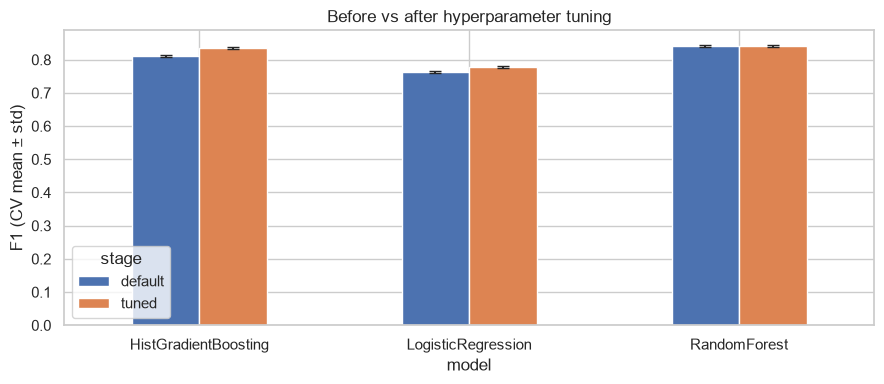

saved figure -> outputs\figures\7_before_after_tuning.png


f1_mean  f1_std  roc_auc_mean  pr_auc_mean  \
model                stage                                                 
LogisticRegression   default   0.7629  0.0021        0.9119       0.8769   
                     tuned     0.7784  0.0032        0.9122       0.8752   
RandomForest         default   0.8422  0.0036        0.9546       0.9358   
                     tuned     0.8419  0.0028        0.9537       0.9338   
HistGradientBoosting default   0.8112  0.0027        0.9417       0.9154   
                     tuned     0.8344  0.0025        0.9496       0.9271   

                              train_f1_mean  gap_f1(train-cv)  fit_time_s  
model                stage                                                 
LogisticRegression   default         0.7641            0.0012      3.3228  
                     tuned           0.7804            0.0020      3.4034  
RandomForest         default         0.9942            0.1521     50.2354  
                     tuned           0.9638            0.1218     44.1276  
HistGradientBoosting default         0.8222            0.0110      5.4569  
                     tuned           0.8961            0.0617      9.4530

In [29]:
tuned_results = pd.DataFrame({
    name: evaluate_cv(make_model(name, FINAL_FEATURES, tuned_params[name]), X_train_f, y_train, train_score=True)
    for name in TUNE_MODELS}).T

compare_rows = []
for name in TUNE_MODELS:
    for stage, res in [('default', default_results.loc[name]), ('tuned', tuned_results.loc[name])]:
        compare_rows.append({'model': name, 'stage': stage, 'f1_mean': res['f1_mean'], 'f1_std': res['f1_std'],
                             'roc_auc_mean': res['roc_auc_mean'], 'pr_auc_mean': res['pr_auc_mean'],
                             'train_f1_mean': res['train_f1_mean'], 'gap_f1(train-cv)': res['gap_f1(train-cv)'],
                             'fit_time_s': res['fit_time_s']})
before_after = pd.DataFrame(compare_rows).set_index(['model', 'stage']).astype(float).round(4)
delta = before_after.xs('tuned', level='stage')['f1_mean'] - before_after.xs('default', level='stage')['f1_mean']
print('F1 เปลี่ยนแปลงหลัง tuning:\n', delta.round(4).to_string())
save_table(before_after, '7_before_after_tuning')

plot_ba = before_after['f1_mean'].unstack('stage')[['default', 'tuned']]
ax = plot_ba.plot(kind='bar', yerr=before_after['f1_std'].unstack('stage')[['default', 'tuned']],
                  capsize=4, figsize=(9, 4), rot=0)
ax.set_ylabel('F1 (CV mean ± std)')
ax.set_title('Before vs after hyperparameter tuning')
save_fig('7_before_after_tuning')
before_after

### 7.4 Validation Curve และ Learning Curve
- **Validation Curve** (`max_depth` ของ Random Forest): ถ้าคะแนน train สูงขึ้นแต่ validation ไม่ขึ้นหรือลดลง = overfitting → ใช้อธิบายว่า "ทำไมเลือกค่านี้"
- **Learning Curve** (โมเดลที่ดีที่สุด): ดูว่าเพิ่มข้อมูลแล้วจะดีขึ้นอีกไหม

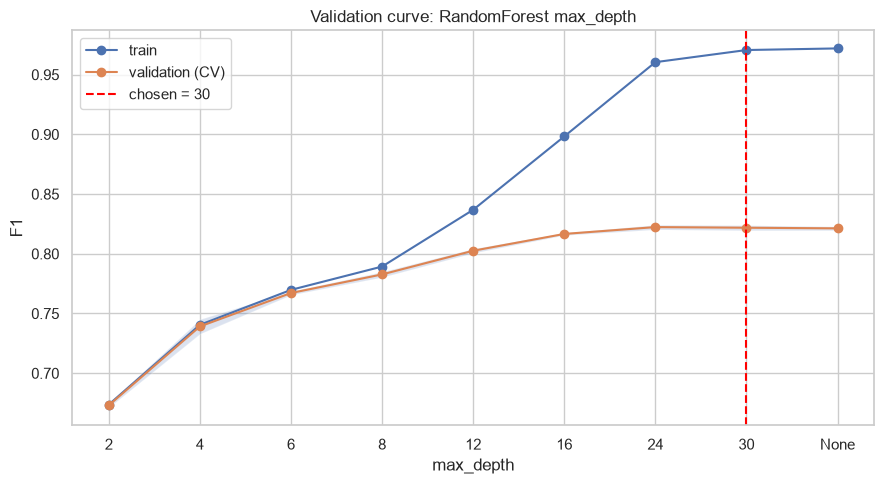

saved figure -> outputs\figures\7_validation_curve_rf_max_depth.png
saved table  -> outputs\tables\7_validation_curve_rf_max_depth.csv
โมเดลที่ CV F1 สูงสุดหลัง tuning = RandomForest


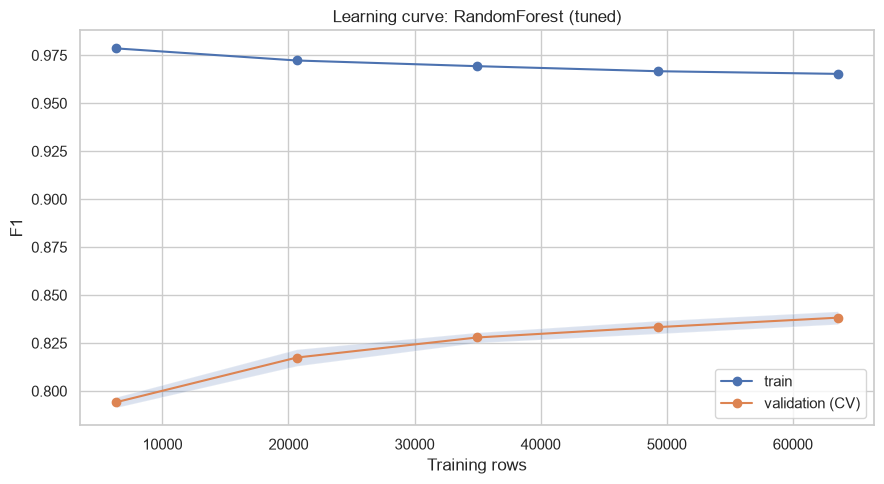

saved figure -> outputs\figures\7_learning_curve.png


In [30]:
chosen_depth = tuned_params['RandomForest']['model__max_depth']
depths = sorted({2, 4, 6, 8, 12, 16, 24} | ({chosen_depth} if chosen_depth is not None else set())) + [None]
rf_fixed = {k: v for k, v in tuned_params['RandomForest'].items() if k != 'model__max_depth'}
train_sc, val_sc = validation_curve(make_model('RandomForest', FINAL_FEATURES, rf_fixed), X_tune, y_tune,
                                    param_name='model__max_depth', param_range=depths, cv=CV3,
                                    scoring='f1', n_jobs=-1)
labels = [str(d) for d in depths]
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(labels, train_sc.mean(axis=1), marker='o', label='train')
ax.plot(labels, val_sc.mean(axis=1), marker='o', label='validation (CV)')
ax.fill_between(labels, val_sc.mean(axis=1) - val_sc.std(axis=1), val_sc.mean(axis=1) + val_sc.std(axis=1), alpha=0.2)
ax.axvline(labels.index(str(chosen_depth)), color='red', ls='--', label=f'chosen = {chosen_depth}')
ax.set_xlabel('max_depth')
ax.set_ylabel('F1')
ax.set_title('Validation curve: RandomForest max_depth')
ax.legend()
save_fig('7_validation_curve_rf_max_depth')
save_table(pd.DataFrame({'max_depth': labels, 'train_f1': train_sc.mean(axis=1),
                         'val_f1': val_sc.mean(axis=1), 'val_std': val_sc.std(axis=1)}).set_index('max_depth').round(4),
           '7_validation_curve_rf_max_depth')

BEST_MODEL = tuned_results['f1_mean'].astype(float).idxmax()
print('โมเดลที่ CV F1 สูงสุดหลัง tuning =', BEST_MODEL)

sizes, lc_train, lc_val = learning_curve(make_model(BEST_MODEL, FINAL_FEATURES, tuned_params[BEST_MODEL]),
                                         X_train_f, y_train, train_sizes=np.linspace(0.1, 1.0, 5),
                                         cv=CV3, scoring='f1', n_jobs=-1, shuffle=True, random_state=RANDOM_STATE)
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sizes, lc_train.mean(axis=1), marker='o', label='train')
ax.plot(sizes, lc_val.mean(axis=1), marker='o', label='validation (CV)')
ax.fill_between(sizes, lc_val.mean(axis=1) - lc_val.std(axis=1), lc_val.mean(axis=1) + lc_val.std(axis=1), alpha=0.2)
ax.set_xlabel('Training rows')
ax.set_ylabel('F1')
ax.set_title(f'Learning curve: {BEST_MODEL} (tuned)')
ax.legend()
save_fig('7_learning_curve')

### 7.5 Threshold Tuning
โมเดลใช้ threshold 0.5 เป็นค่าเริ่มต้น แต่ไม่จำเป็นต้องดีที่สุด หา threshold ที่ให้ F1 สูงสุดจาก
**out-of-fold predictions บน train** (ไม่แตะ test set)

threshold 0.50 -> OOF F1 = 0.8386
threshold 0.46 -> OOF F1 = 0.8394  <- ใช้ค่านี้


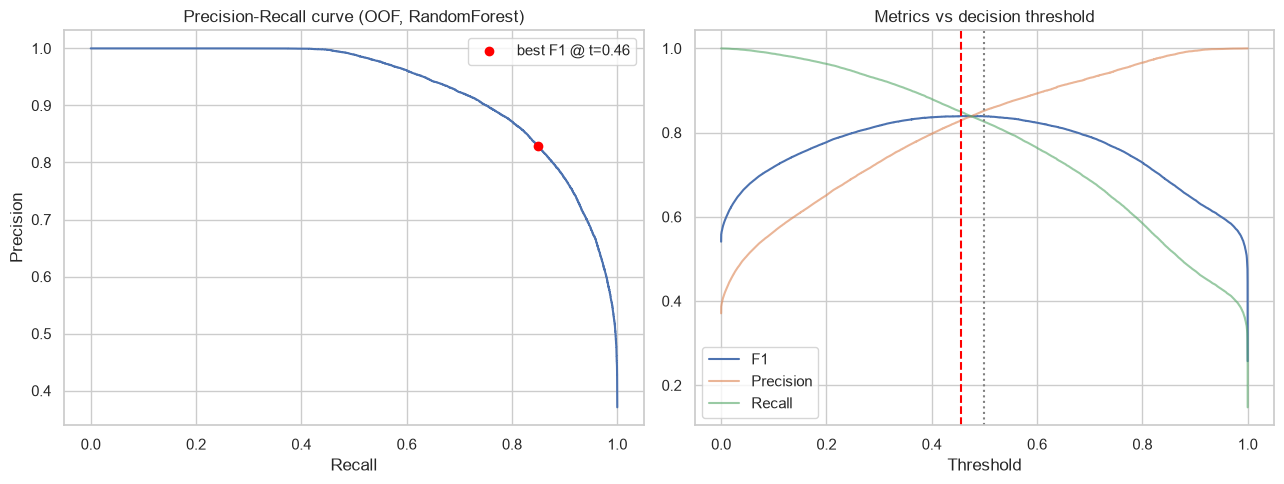

saved figure -> outputs\figures\7_threshold_tuning.png


In [31]:
best_pipe = make_model(BEST_MODEL, FINAL_FEATURES, tuned_params[BEST_MODEL])
oof_proba = cross_val_predict(best_pipe, X_train_f, y_train, cv=CV3, method='predict_proba', n_jobs=-1)[:, 1]
prec, rec, thr = precision_recall_curve(y_train, oof_proba)
f1s = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
best_i = int(np.argmax(f1s))
THRESHOLD = float(thr[best_i])
f1_at_05 = f1_score(y_train, (oof_proba >= 0.5).astype(int))
print(f'threshold 0.50 -> OOF F1 = {f1_at_05:.4f}')
print(f'threshold {THRESHOLD:.2f} -> OOF F1 = {f1s[best_i]:.4f}  <- ใช้ค่านี้')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(rec, prec)
axes[0].scatter(rec[best_i], prec[best_i], color='red', zorder=3, label=f'best F1 @ t={THRESHOLD:.2f}')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title(f'Precision-Recall curve (OOF, {BEST_MODEL})'); axes[0].legend()
axes[1].plot(thr, f1s, label='F1')
axes[1].plot(thr, prec[:-1], label='Precision', alpha=0.6)
axes[1].plot(thr, rec[:-1], label='Recall', alpha=0.6)
axes[1].axvline(THRESHOLD, color='red', ls='--'); axes[1].axvline(0.5, color='grey', ls=':')
axes[1].set_xlabel('Threshold'); axes[1].set_title('Metrics vs decision threshold'); axes[1].legend()
save_fig('7_threshold_tuning')

### 7.6 ประเมินบน Test Set (ครั้งเดียว)
เลือกโมเดลด้วย CV แล้ว ตอนนี้จึงประเมินทุกโมเดลที่ tuning แล้วบน test set เพื่อรายงานผลจริง

saved table  -> outputs\tables\7_test_set_results.csv


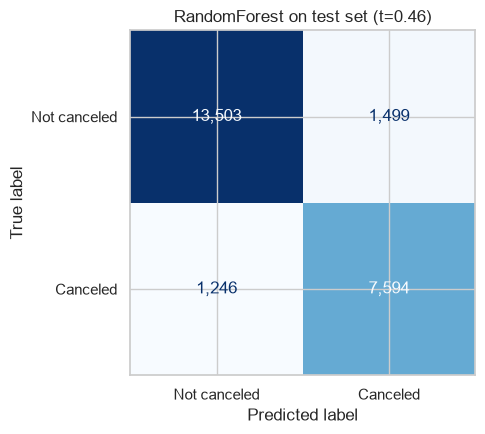

saved figure -> outputs\figures\7_confusion_matrix.png
              precision    recall  f1-score   support

Not canceled     0.9155    0.9001    0.9077     15002
    Canceled     0.8351    0.8590    0.8469      8840

    accuracy                         0.8849     23842
   macro avg     0.8753    0.8796    0.8773     23842
weighted avg     0.8857    0.8849    0.8852     23842



,threshold,f1,precision,recall,accuracy,roc_auc,pr_auc,fit_time_s,predict_ms_per_1000_rows
LogisticRegression (t=0.50),0.5000,0.7782,0.7423,0.8176,0.8272,0.9123,0.8757,2.7980,5.9835
RandomForest (t=0.50),0.5000,0.8440,0.8552,0.8331,0.8858,0.9567,0.9367,15.0021,22.2166
RandomForest (t=0.46),0.4562,0.8469,0.8351,0.8590,0.8849,0.9567,0.9367,NaN,NaN
HistGradientBoosting (t=0.50),0.5000,0.8355,0.8116,0.8610,0.8743,0.9524,0.9298,9.6104,16.4245


In [32]:
final_models, test_rows = {}, {}
for name in TUNE_MODELS:
    pipe = make_model(name, FINAL_FEATURES, tuned_params[name])
    t0 = time.time(); pipe.fit(X_train_f, y_train); fit_s = time.time() - t0
    t0 = time.time(); proba = pipe.predict_proba(X_test_f)[:, 1]; pred_ms = (time.time() - t0) / len(X_test_f) * 1000 * 1000
    final_models[name] = (pipe, proba)
    row = test_metrics(y_test, proba, 0.5)
    row.update({'fit_time_s': fit_s, 'predict_ms_per_1000_rows': pred_ms})
    test_rows[f'{name} (t=0.50)'] = row
    if name == BEST_MODEL:
        test_rows[f'{name} (t={THRESHOLD:.2f})'] = test_metrics(y_test, proba, THRESHOLD)

test_table = pd.DataFrame(test_rows).T.astype(float).round(4)
save_table(test_table, '7_test_set_results')

final_pipe, final_proba = final_models[BEST_MODEL]
final_pred = (final_proba >= THRESHOLD).astype(int)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, final_pred, display_labels=['Not canceled', 'Canceled'],
                                        cmap='Blues', values_format=',', ax=ax, colorbar=False)
ax.set_title(f'{BEST_MODEL} on test set (t={THRESHOLD:.2f})')
save_fig('7_confusion_matrix')
print(classification_report(y_test, final_pred, target_names=['Not canceled', 'Canceled'], digits=4))
test_table

### 7.7 Random Split vs Time-based Split
ในการใช้งานจริง โมเดลต้องทำนาย**อนาคต**จากข้อมูล**อดีต** ถ้าผลแบบแบ่งตามเวลาต่ำกว่าแบบสุ่ม
แปลว่าการสุ่มแบ่งประเมินโมเดล**สูงเกินจริง**

In [33]:
time_pipe = make_model(BEST_MODEL, FINAL_FEATURES, tuned_params[BEST_MODEL])
time_pipe.fit(time_train[FINAL_FEATURES], time_train[TARGET])
time_proba = time_pipe.predict_proba(time_test[FINAL_FEATURES])[:, 1]

split_compare = pd.DataFrame({
    'random split (t=0.50)': test_metrics(y_test, final_proba, 0.5),
    f'random split (t={THRESHOLD:.2f})': test_metrics(y_test, final_proba, THRESHOLD),
    'time split (t=0.50)': test_metrics(time_test[TARGET], time_proba, 0.5),
    f'time split (t={THRESHOLD:.2f})': test_metrics(time_test[TARGET], time_proba, THRESHOLD),
}).T.astype(float).round(4)
save_table(split_compare, '7_random_vs_time_split')
split_compare

saved table  -> outputs\tables\7_random_vs_time_split.csv


,threshold,f1,precision,recall,accuracy,roc_auc,pr_auc
random split (t=0.50),0.5000,0.8440,0.8552,0.8331,0.8858,0.9567,0.9367
random split (t=0.46),0.4562,0.8469,0.8351,0.8590,0.8849,0.9567,0.9367
time split (t=0.50),0.5000,0.7067,0.8160,0.6233,0.7880,0.8718,0.8343
time split (t=0.46),0.4562,0.7249,0.7996,0.6630,0.7938,0.8718,0.8343


### 7.8 Error Analysis: โมเดลแม่น/พลาดในกลุ่มไหน

In [34]:
test_info = df.loc[X_test.index, ['hotel', 'distribution_channel', 'deposit_type', 'customer_type']].copy()
test_info['y_true'] = y_test.values
test_info['y_pred'] = final_pred
min_n = 30 if QUICK_RUN else 100

err_rows = []
for col in ['hotel', 'distribution_channel', 'deposit_type', 'customer_type']:
    for value, g in test_info.groupby(col):
        if len(g) < min_n:
            continue
        err_rows.append({'group': col, 'value': value, 'n': len(g),
                         'actual_cancel_rate': g['y_true'].mean(), 'predicted_cancel_rate': g['y_pred'].mean(),
                         'precision': precision_score(g['y_true'], g['y_pred'], zero_division=0),
                         'recall': recall_score(g['y_true'], g['y_pred'], zero_division=0),
                         'f1': f1_score(g['y_true'], g['y_pred'], zero_division=0)})
error_table = pd.DataFrame(err_rows).set_index(['group', 'value']).round(4)
save_table(error_table, '7_error_analysis')
error_table

saved table  -> outputs\tables\7_error_analysis.csv


n  actual_cancel_rate  \
group                value                                        
hotel                City Hotel       15731              0.4240   
                     Resort Hotel      8111              0.2675   
distribution_channel Corporate         1372              0.2201   
                     Direct            2972              0.1672   
                     TA/TO            19462              0.4127   
deposit_type         No Deposit       20892              0.2838   
                     Non Refund        2919              0.9945   
customer_type        Contract           841              0.2949   
                     Group              134              0.1119   
                     Transient        17857              0.4081   
                     Transient-Party   5010              0.2575   

                                      predicted_cancel_rate  precision  \
group                value                                               
hotel                City Hotel                      0.4345     0.8470   
                     Resort Hotel                    0.2784     0.7994   
distribution_channel Corporate                       0.1866     0.9141   
                     Direct                          0.1198     0.7893   
                     TA/TO                           0.4355     0.8349   
deposit_type         No Deposit                      0.2961     0.7578   
                     Non Refund                      0.9938     0.9997   
customer_type        Contract                        0.3103     0.8966   
                     Group                           0.1119     0.7333   
                     Transient                       0.4236     0.8196   
                     Transient-Party                 0.2499     0.9177   

                                      recall      f1  
group                value                            
hotel                City Hotel       0.8679  0.8573  
                     Resort Hotel     0.8318  0.8153  
distribution_channel Corporate        0.7748  0.8387  
                     Direct           0.5654  0.6589  
                     TA/TO            0.8811  0.8574  
deposit_type         No Deposit       0.7906  0.7739  
                     Non Refund       0.9990  0.9993  
customer_type        Contract         0.9435  0.9194  
                     Group            0.7333  0.7333  
                     Transient        0.8508  0.8349  
                     Transient-Party  0.8907  0.9040

### 7.9 บันทึกโมเดลสุดท้าย

In [35]:
PREP_COLUMNS = [c for c in df.columns if c not in [TARGET] + ENGINEERED_FEATURES]
DEFAULTS = {c: (float(df[c].median()) if pd.api.types.is_numeric_dtype(df[c]) else df[c].mode()[0])
            for c in PREP_COLUMNS if c != 'arrival_date'}

bundle = {'pipeline': final_pipe, 'model_name': BEST_MODEL, 'threshold': THRESHOLD,
          'features': FINAL_FEATURES, 'defaults': DEFAULTS, 'params': tuned_params[BEST_MODEL]}
model_path = os.path.join(MODEL_DIR, 'hotel_cancel_model.joblib')
joblib.dump(bundle, model_path)
print('saved model ->', model_path, f'({os.path.getsize(model_path) / 1e6:.1f} MB)')

saved model -> outputs\models\hotel_cancel_model.joblib (356.8 MB)


## 8. Deploy (หัวข้อ 8)
### 8.1 ฟังก์ชันทำนาย + ตัวอย่าง Input → Output
ผู้ใช้กรอกเฉพาะข้อมูลสำคัญ ส่วนที่เหลือเติมด้วยค่าที่พบบ่อยที่สุดจากข้อมูล train

In [36]:
def predict_booking(arrival_date='2017-08-15', **inputs):
    row = dict(DEFAULTS)
    date = pd.Timestamp(arrival_date)
    row.update(arrival_date=date, arrival_date_year=date.year, arrival_date_month=date.month,
               arrival_date_week_number=int(date.isocalendar()[1]), arrival_date_day_of_month=date.day)
    row.update(inputs)
    one = add_features(pd.DataFrame([row]))
    return float(final_pipe.predict_proba(one[FINAL_FEATURES])[0, 1])


examples = {
    'A: long lead time, non-refundable, group': dict(hotel='City Hotel', lead_time=300, deposit_type='Non Refund',
        market_segment='Groups', customer_type='Transient', total_of_special_requests=0,
        required_car_parking_spaces=0, previous_cancellations=1, is_repeated_guest=0, country='PRT'),
    'B: short lead time, direct, repeat guest': dict(hotel='Resort Hotel', lead_time=5, deposit_type='No Deposit',
        market_segment='Direct', customer_type='Transient', total_of_special_requests=2,
        required_car_parking_spaces=1, previous_cancellations=0, is_repeated_guest=1, country='GBR'),
    'C: medium lead time, online TA': dict(hotel='City Hotel', lead_time=60, deposit_type='No Deposit',
        market_segment='Online TA', customer_type='Transient', total_of_special_requests=1,
        required_car_parking_spaces=0, previous_cancellations=0, is_repeated_guest=0, country='FRA'),
}
example_rows = []
for label, inp in examples.items():
    p = predict_booking(**inp)
    example_rows.append({'example': label, **inp, 'cancel_probability': round(p, 4),
                         'prediction': 'HIGH risk' if p >= THRESHOLD else 'low risk'})
example_table = pd.DataFrame(example_rows).set_index('example')
save_table(example_table, '8_deploy_examples')
example_table[['lead_time', 'deposit_type', 'market_segment', 'cancel_probability', 'prediction']]

saved table  -> outputs\tables\8_deploy_examples.csv


,lead_time,deposit_type,market_segment,cancel_probability,prediction
example,,,,,
"A: long lead time, non-refundable, group",300,Non Refund,Groups,0.9979,HIGH risk
"B: short lead time, direct, repeat guest",5,No Deposit,Direct,0.0096,low risk
"C: medium lead time, online TA",60,No Deposit,Online TA,0.2590,low risk


### 8.2 Web Demo ด้วย Gradio
รัน 2 cell ด้านล่างแล้วจะได้ลิงก์ `https://....gradio.live` สำหรับเปิดบนมือถือหรือคอมเครื่องอื่น (ลิงก์ใช้ได้ชั่วคราวระหว่างที่ Colab ยังรันอยู่)

In [37]:
# COLAB_ONLY
%pip install -q gradio

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [38]:
# COLAB_ONLY
import gradio as gr

choices = lambda col: sorted(df[col].astype(str).unique().tolist())


def gr_predict(hotel, arrival_date, lead_time, weekend_nights, week_nights, adults, children,
               deposit_type, market_segment, customer_type, adr, special_requests,
               previous_cancellations, parking, repeated_guest, country):
    p = predict_booking(arrival_date=arrival_date, hotel=hotel, lead_time=int(lead_time),
                        stays_in_weekend_nights=int(weekend_nights), stays_in_week_nights=int(week_nights),
                        adults=int(adults), children=int(children), deposit_type=deposit_type,
                        market_segment=market_segment, customer_type=customer_type, adr=float(adr),
                        total_of_special_requests=int(special_requests),
                        previous_cancellations=int(previous_cancellations),
                        required_car_parking_spaces=int(parking), is_repeated_guest=int(repeated_guest),
                        country=country.strip().upper())
    risk = 'เสี่ยงสูงที่จะถูกยกเลิก' if p >= THRESHOLD else 'เสี่ยงต่ำ'
    return f'ความน่าจะเป็นที่จะยกเลิก: {p:.1%}\nผลการทำนาย: {risk} (threshold = {THRESHOLD:.2f})'


demo = gr.Interface(
    fn=gr_predict,
    inputs=[gr.Dropdown(choices('hotel'), value='City Hotel', label='Hotel'),
            gr.Textbox(value='2017-08-15', label='Arrival date (YYYY-MM-DD)'),
            gr.Number(value=60, label='Lead time (days)'),
            gr.Number(value=1, label='Weekend nights'), gr.Number(value=2, label='Week nights'),
            gr.Number(value=2, label='Adults'), gr.Number(value=0, label='Children'),
            gr.Dropdown(choices('deposit_type'), value='No Deposit', label='Deposit type'),
            gr.Dropdown(choices('market_segment'), value='Online TA', label='Market segment'),
            gr.Dropdown(choices('customer_type'), value='Transient', label='Customer type'),
            gr.Number(value=100, label='ADR (price per night)'),
            gr.Slider(0, 5, value=0, step=1, label='Special requests'),
            gr.Number(value=0, label='Previous cancellations'),
            gr.Slider(0, 3, value=0, step=1, label='Car parking spaces'),
            gr.Checkbox(value=False, label='Repeated guest'),
            gr.Textbox(value='PRT', label='Country code (ISO-3)')],
    outputs=gr.Textbox(label='Result'),
    title='Hotel Booking Cancellation Predictor',
    description=f'Model: {BEST_MODEL} (tuned) | threshold = {THRESHOLD:.2f}',
)
demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


## สรุปไฟล์หลักฐาน + ดาวน์โหลด
ชื่อไฟล์ขึ้นต้นด้วยเลขหัวข้อรายงาน (`3_`, `4_`, `5_`, `6_`, `7_`, `8_`) นำไปแนบรายงานได้ทันที
cell นี้รวมทุกไฟล์เป็น `hotel_outputs.zip` แล้วดาวน์โหลดลงเครื่อง (ถ้า browser บล็อก ให้คลิกขวาที่ไฟล์ zip ในแถบ Files → Download)

In [39]:
import shutil
for folder in (FIG_DIR, TABLE_DIR, MODEL_DIR):
    print(f'\n{folder}')
    for f in sorted(os.listdir(folder)):
        print('  ', f)

zip_path = shutil.make_archive(os.path.join(os.path.dirname(os.path.abspath(OUTPUT_DIR)), 'hotel_outputs'),
                               'zip', OUTPUT_DIR)
print('\nzip ->', zip_path)
if IN_COLAB:
    from google.colab import files
    files.download(zip_path)


outputs\figures
   3_eda_cancel_rate_by_category.png
   3_eda_lead_time_and_adr.png
   3_target_distribution.png
   5_correlation_heatmap.png
   5_engineered_features_cancel_rate.png
   5_mutual_information.png
   5_performance_vs_k.png
   5_permutation_importance.png
   5_random_forest_importance.png
   6_default_models_f1.png
   7_before_after_tuning.png
   7_confusion_matrix.png
   7_learning_curve.png
   7_threshold_tuning.png
   7_validation_curve_rf_max_depth.png

outputs\tables
   3_column_summary.csv
   4_leakage_check_assigned_room.csv
   4_preparation_log.csv
   4_split_summary.csv
   5_engineered_features_spread.csv
   5_feature_set_comparison.csv
   5_feature_vote_table.csv
   5_high_correlation_pairs.csv
   5_performance_vs_k.csv
   6_default_models_cv.csv
   7_baseline.csv
   7_before_after_tuning.csv
   7_error_analysis.csv
   7_grid_search_refinement.csv
   7_random_search_HistGradientBoosting.csv
   7_random_search_LogisticRegression.csv
   7_random_search_RandomFores